# Домашнее задание 3: сверточные сети, transfer learning и open‑source модели CV

**Цели:**
1. Понять, как работают базовые свёрточные сети (CNN) на примере задачи классификации изображений.
2. Научиться использовать **предобученные модели** и подход **transfer learning** (дообучение ResNet).
3. Научиться запускать и применять **open‑source модели компьютерного зрения**:
   - UNet для сегментации
   - YOLO для детекции объектов
   - SAM и CLIP (и опционально CoTracker) — как примеры современных моделей из коробки

Во всех частях мы **максимально упрощаем код**, даём скелеты и пояснения. Ваша основная задача — **запустить код, немного его изменить и ответить на вопросы**.



## Общие рекомендации

* Работайте в Google Colab или другой среде с поддержкой GPU (опционально, но желательно). Подключение GPU в google.colab: **Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**
* Ячейки `!pip install ...` можно запускать целиком, не нужно их менять.
* В коде встречаются блоки `# TODO:` — это те места, где нужно слегка дополнить/изменить код.
* После каждой смысловой части есть **вопросы** с двумя полями:

- **Ответ LLMки:** сюда вы можете вставить ответ, который получите от модели (ChatGPT / др.).  
- **Ваш ответ:** сюда вы формулируете свой собственный ответ (можно основываясь на объяснении модели, но своими словами).
* Задачи с пометкой **(Опционально)** могут принести вам дополнительные баллы в зависимости от качества решения.

Писать ответы можно прямо в ячейках Markdown (двойной клик по ячейке → редактировать).


**Система оценивания** остается прежней, только теперь в соответствии с новыми сроками выполнения.


---
# Часть 1 (5 баллов). Базовая классификация изображений на свёрточной сети

В этой части мы:

1. Загрузим небольшой датасет картинок (**CIFAR10**).
2. Построим простую свёрточную нейросеть «с нуля».
3. Добавим аугментации данных (случайные преобразования картинок).
4. Сравним нашу сеть с предобученной моделью **ResNet** и посмотрим на transfer learning.
5. (Опционально) Подключим логирование экспериментов в **Weights & Biases (wandb)**.


In [ ]:
# Базовые импорты для работы с PyTorch и обучением моделей
import torch                          # Основная библиотека PyTorch
import torch.nn as nn                 # Модуль для слоев нейросетей
import torch.nn.functional as F       # Функции активации, потери и пр. без состояния
import torch.optim as optim           # Оптимизаторы (SGD, Adam и др.)
import torchvision                    # Утилиты и датасеты для компьютерного зрения
import torchvision.transforms as transforms  # Преобразования и аугментации изображений
from torch.utils.data import DataLoader       # Загрузчик данных батчами
from torch.optim.lr_scheduler import StepLR   # Планировщик изменения learning rate
import torchvision.models as models

from collections import defaultdict    # Удобный словарь с значением по умолчанию
from tqdm.notebook import trange       # Прогресс-бар для циклов в Jupyter

import matplotlib.pyplot as plt        # Визуализация графиков и изображений
import random                          # Стандартный генератор случайных чисел Python
import numpy as np                     # Работа с массивами и численными вычислениями

from sklearn.model_selection import train_test_split  # Разбиение данных на train/test

from pathlib import Path               # Удобная работа с путями к файлам

# Фиксируем сиды для воспроизводимости результатов
def set_seed(seed=42):
    random.seed(seed)                 # Фиксируем случайность в стандартной библиотеке
    np.random.seed(seed)              # Фиксируем случайность в NumPy
    torch.manual_seed(seed)           # Фиксируем случайность для PyTorch (CPU)
    torch.cuda.manual_seed_all(seed)  # Фиксируем случайность для всех GPU (если есть)

set_seed(42)                          # Устанавливаем фиксированный seed

# Определяем устройство: GPU (cuda), если доступно, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

Используемое устройство: cpu



## 1.1. Загрузка данных

Мы будем использовать стандартный датасет [**CIFAR10**](https://www.cs.toronto.edu/~kriz/cifar.html) из `torchvision.datasets`. В нём 10 классов (самолёт, автомобиль, птица, кот и т.п.), а каждое изображение — размером 32×32 пикселя.

Ниже уже написан код, который:

1. Описывает базовые преобразования (`ToTensor`, нормализация).
2. Загружает train/val/test выборки.
3. Оборачивает их в `DataLoader` для удобной итерации по батчам.


In [ ]:
# Преобразования без аугментаций (просто перевод в тензор + нормализация)
transform_base = transforms.Compose([
    transforms.ToTensor(),                # TODO: преобразование в тензор изображений,
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

# Загружаем датасет
train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_base
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_base
)

# Разделим train на train и val
val_size = 5000
train_size = len(train_full) - val_size  # TODO: размер обучающей выборки
g = torch.Generator().manual_seed(42)  # чтобы разбиение было воспроизводимым
train_dataset, val_dataset = torch.utils.data.random_split(train_full, [train_size, val_size], generator=g) # TODO: разделить через sklearn или torch

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # TODO: создайте загрузчик данных
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)  # TODO: создайте загрузчик данных
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)  # TODO: создайте загрузчик данных

len(train_dataset), len(val_dataset), len(test_dataset)

(45000, 5000, 10000)


## 1.2. Визуализация нескольких изображений

Давайте посмотрим, как выглядят картинки и какие у них классы.


Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


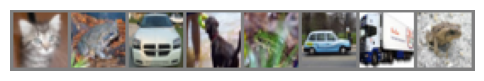

Метки классов для показанных изображений:
['cat', 'frog', 'automobile', 'dog', 'frog', 'automobile', 'truck', 'frog']


In [ ]:
classes = train_dataset.dataset.classes  # названия классов CIFAR10
print("Классы:", classes)

def imshow(img):
    # денормализуем
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(6, 3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print("Метки классов для показанных изображений:")
print([classes[l] for l in labels[:8]])



### Вопрос 1. Зачем нам вообще свёрточный слой?

Попробуйте своими словами объяснить, зачем в задачах с картинками используют **свёртки**, а не только полносвязные слои.

**Ответ LLMки:**
*(сюда вставьте объяснение, которое дала вам модель)*

Свёрточный слой используют, потому что у картинок есть пространственная структура (соседние пиксели связаны), и свёртки умеют эту структуру эффективно использовать.

Локальные признаки. Маленький фильтр (например 3×3) “смотрит” на небольшие кусочки изображения и учится находить простые паттерны: края, углы, текстуры. Полносвязный слой сразу смешивает все пиксели и “не знает”, кто с кем рядом.

Один фильтр — по всей картинке (weight sharing). Один и тот же набор весов применяется в разных местах изображения. Поэтому модель автоматически становится более устойчивой к сдвигам объекта: кот слева и кот справа всё равно распознаются. Полносвязному слою пришлось бы отдельно учить “кота в каждом месте”.

Сильно меньше параметров. Для 32×32×3 входа полносвязный слой на 1000 нейронов — это миллионы весов. Свёртка 3×3×3 на 64 фильтра — это всего тысячи. Меньше параметров → быстрее обучение, меньше переобучение, меньше памяти.

Иерархия признаков. Стопка свёрток строит “пирамиду”: сначала края/текстуры, потом части объектов, потом целые объекты. Это естественно для изображений.

Итого: свёртки дают локальность + переносимость по позиции + экономию параметров, поэтому почти всегда лучше подходят для изображений, чем чисто полносвязные сети.

**Ваш ответ:**  
*(сформулируйте своими словами, можно опираясь на подсказку выше)*

Сверточные слои используют гораздо меньше параметров, что позволяет использовать гораздо меньше вычислительных ресурсов и сокращать время на обработку информации, модель обучается быстрее и меньше переобучается.

При этом они учитывают пространственную сотруктуру, т.е. данные не только о самом пикселе, но и его "окрестностях", т.е. учитывают взаимосвязи в визуальных объектах, распознают объект вне зависимости от его места на картинке, т.е. учитывают возможный сдвиг объекта.

Также несколько сверточных слоев обзазуют иерархию признаков, от простых к сложным (сначала - детали объекта, потом - его части, а затем - весь объект целиком), что логично для распознавания изображений, так как делает этот процесс и более быстрым, и более устойчивым к ошибкам.


## 1.3. Простая свёрточная сеть (с нуля)

Ниже — очень простая архитектура:

- два блока: `Conv2d → ReLU → BatchNorm → MaxPool`,
- затем «разворачиваем» тензор в вектор и подаём в два полносвязных слоя, между которыми Dropout.

In [ ]:
class VerySimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Блок 1: 3x32x32 -> 16x16x16
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2, stride=2),    # TODO: слои первого блока
        )

        # Блок 2: 16x16x16 -> 32x8x8
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),    # TODO: слои второго блока
        )

        # После двух пуллингов: 32x32 -> 16x16 -> 8x8, каналов 32
        self.flatten_dim = 32 * 8 * 8  # TODO: посчитайте размерность входа в линейный слой после сверток
        # Например, после двух пуллингов размер 32x32 станет 8x8 (32 -> 16 -> 8)

        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.drop = nn.Dropout(p=0.2)  # TODO: создайте дропаут и выберите вероятность выбрасывать нейрон; лучше взять небольшую
        self.fc2 = nn.Linear(128, num_classes) # TODO

    def forward(self, x):
        after_block_1 = self.block_1(x) # TODO
        after_block_2 = self.block_2(after_block_1) # TODO
        after_conv    = torch.flatten(after_block_2, start_dim=1) # TODO: "разворачиваем" тензор в вектор

        result = self.fc2(self.drop(F.relu(self.fc1(after_conv)))) # TODO
        return result


very_simple_model = VerySimpleCNN(num_classes=10).to(device) # TODO: модель, не забудьте про устройство
print(very_simple_model)

VerySimpleCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (drop): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)



## 1.4. Функции обучения и проверки качества

Ниже функции:

- `train_one_epoch` — один проход по train-данным,
- `evaluate` — оценка качества (loss и accuracy) на валидации или тесте,
- `train_model` — простой цикл по эпохам.

In [ ]:
def test(model, loader):
    # TODO: переведите модель в режим тестирования
    model.eval()  # режим тестирования
    loss_fn = nn.CrossEntropyLoss() # TODO: создайте объект класса CrossEntropyLoss

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader: # TODO: итерируйтесь по данным:
            data = data.to(device)  # TODO: переведите данные на device
            target = target.to(device)

            output = model(data) # TODO: посчитайте предсказания для батча
            loss = loss_fn(output, target) # TODO: посчитайте ошибку для батча

            # аккуратное усреднение по всем примерам
            batch_size = target.size(0)
            total_loss += loss.item() * batch_size
            correct += (output.argmax(dim=1) == target).sum().item()
            total += batch_size

    mean_loss = total_loss / total
    mean_acc = correct / total
    return mean_loss, mean_acc



def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    # TODO: переведите модель в режим обучения
    model.train()  # режим обучения
    loss_fn = nn.CrossEntropyLoss() # TODO: создайте объект класса CrossEntropyLoss

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device) # TODO: итерируйтесь по данным

        optimizer.zero_grad()          # TODO: удалите использованные градиенты
        output = model(data)           # TODO: посчитайте предсказания для батча
        loss = loss_fn(output, target) # TODO: посчитайте ошибку для батча
        loss.backward()                # TODO: backpropagation
        optimizer.step()               # TODO: обновите параметры

        loss_log.append(loss.item())

        predictions = output.argmax(dim=1)
        accuracy = (predictions == target).float().mean().item() # TODO: посчитайте долю угаданных классов изображений

        acc_log.append(accuracy)

    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Эпоха {epoch+1}/{n_epochs} | "
              f"train loss: {np.mean(train_loss):.4f}, train acc: {np.mean(train_acc):.3f} | "
              f"val loss: {val_loss:.4f}, val acc: {val_acc:.3f}")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log



## 1.5. Обучаем нашу простую CNN

Запустите обучение на 3–5 эпохах (чтобы не ждать слишком долго) и посмотрите на точность. Но если есть время и желание подождать, то лучше обучить на 10-20 эпохах.


In [ ]:
very_simple_model = VerySimpleCNN(num_classes=10).to(device) # TODO: проинициализируйте модели и положите ее на устройство
optimizer = optim.Adam(very_simple_model.parameters(), lr=1e-3, weight_decay=1e-4) # TODO: создайте adam оптимизатор
scheduler = StepLR(optimizer, step_size=2, gamma=0.5) # TODO: попробуйте добавить обновление learning rate, https://docs.pytorch.org/docs/stable/optim.html
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(very_simple_model, optimizer, 10,
                                                                 train_loader, val_loader, scheduler=scheduler)

Эпоха 1/10 | train loss: 1.2728, train acc: 0.545 | val loss: 1.0341, val acc: 0.635
Эпоха 2/10 | train loss: 0.9586, train acc: 0.661 | val loss: 0.9427, val acc: 0.674
Эпоха 3/10 | train loss: 0.7364, train acc: 0.739 | val loss: 0.8470, val acc: 0.701
Эпоха 4/10 | train loss: 0.6368, train acc: 0.775 | val loss: 0.8152, val acc: 0.714
Эпоха 5/10 | train loss: 0.5043, train acc: 0.823 | val loss: 0.8140, val acc: 0.721
Эпоха 6/10 | train loss: 0.4479, train acc: 0.844 | val loss: 0.8269, val acc: 0.724
Эпоха 7/10 | train loss: 0.3721, train acc: 0.876 | val loss: 0.8378, val acc: 0.728
Эпоха 8/10 | train loss: 0.3449, train acc: 0.885 | val loss: 0.8440, val acc: 0.725
Эпоха 9/10 | train loss: 0.3098, train acc: 0.898 | val loss: 0.8587, val acc: 0.725
Эпоха 10/10 | train loss: 0.2948, train acc: 0.903 | val loss: 0.8630, val acc: 0.725


In [ ]:
# Оценка на тестовой выборке
test_loss, test_acc = test(very_simple_model, test_loader)
print(f'Точность на тестовой выборке: {test_acc:.4f}')

Точность на тестовой выборке: 0.7327


In [ ]:
train_eval_loader = DataLoader(train_dataset, batch_size=64, shuffle=False,
                               num_workers=2, pin_memory=(device.type=="cuda"))

def acc_exact(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

print(f"Точность на обучающей выборке: {acc_exact(very_simple_model, train_eval_loader):.4f}")
print(f"Точность на валидационной выборке: {acc_exact(very_simple_model, val_loader):.4f}")
print(f"Точность на тестовой выборке: {acc_exact(very_simple_model, test_loader):.4f}")


Точность на обучающей выборке: 0.9560
Точность на валидационной выборке: 0.7246
Точность на тестовой выборке: 0.7327



### Вопрос 2. Переобучение и недообучение

Сравните точность на **train**, **val** и **test** (если нужно — выведите точность на train, добавив принт в код).

1. Что вы наблюдаете: модель **переобучается**, **недообучается** или ведёт себя более‑менее сбалансированно?
2. Как вы думаете, какие **простые способы** борьбы с переобучением существуют (не обязательно все реализовывать)?
3. Поговорим про **scheduler** (планировщик скорости обучения): какие они бывают? В чём их смысл?

**Ответ LLMки:**  
### 1. Модель переобучается, недообучается или сбалансирована?

Мы видим:

* на **train** модель почти идеальна: `~96%` точности;
* на **val/test** — существенно ниже: `~72–73%`.

То есть модель **очень хорошо выучила обучающую выборку**, но уже **заметно хуже обобщает** на новых данных.
Это типичный признак **переобучения (overfitting)**:

* разрыв между train и val/test большой;
* при этом валидционная и тестовая точность между собой близки → модель стабильно обобщает, но всё равно лучше “знает” train, чем новые данные.

### 2. Какие простые способы борьбы с переобучением существуют?

Классический набор:

* **Регуляризация весов (L2 / weight decay)**
  Мы уже использовали `weight_decay` в Adam. Увеличение этого параметра заставляет веса быть “поменьше” и мягче, снижает переобучение.

* **Dropout**
  В твоей `VerySimpleCNN` есть `Dropout` в полносвязной части. Можно слегка увеличить вероятность (например, с 0.2 до 0.3–0.4), чтобы сеть меньше переобучалась.

* **Аугментации данных**
  Случайные преобразования картинок: `RandomCrop`, `RandomHorizontalFlip`, `ColorJitter` и т.п. Ты уже делала это в части с аугментациями — это один из самых эффективных способов бороться с переобучением на изображениях.

* **Уменьшение сложности модели**
  Например, меньше каналов в свёрточных слоях или меньше нейронов в полносвязном слое. Тогда модель просто физически не сможет столь сильно “запомнить” train.

* **Early stopping (ранняя остановка)**
  Останавливать обучение, когда **валидационная ошибка перестаёт улучшаться**, даже если train ещё уменьшается.

* **Больше данных**
  Идеальный (но не всегда доступный) способ — больше обучающих примеров.

### 3. Что такое scheduler (планировщик learning rate) и какие они бывают?

**Зачем нужен sheduler?**

* В начале обучения полезен **больший learning rate**, чтобы быстро сходиться.
* Ближе к концу — **уменьшать lr**, чтобы делать более “аккуратные” шаги и не перепрыгивать минимум.
  Это часто даёт более стабильное обучение и чуть лучшую итоговую точность.

**Основные типы scheduler’ов:**

* `StepLR` — lr уменьшается скачками каждые N эпох.
* `MultiStepLR` — уменьшение lr по нескольким заранее заданным эпохам (milestones).
* `ExponentialLR` — lr уменьшается экспоненциально, например `lr_t = lr_0 * γ^t`.
* `CosineAnnealingLR` — lr плавно меняется по косинусной кривой (часто используется в современных моделях).
* `ReduceLROnPlateau` — уменьшает lr, когда метрика на валидации перестала улучшаться.
* `OneCycleLR` / циклические scheduler’ы — сначала увеличивают lr, потом уменьшают; хорошо работают с современными оптимизаторами.

**Ваш ответ:**  
1. Модель демонстрирует признаки переобучения: точность на train (≈96%) заметно выше, чем на val и test (≈72-73%). Это означает, что она частично “запоминает” обучающие данные и не так хорошо обобщает на новых примерах.

2. Простые способы уменьшить переобучение: усилить регуляризацию (weight decay, Dropout), добавить аугментации данных (случайные повороты, обрезки, отражения), уменьшить размер модели, использовать раннюю остановку по валидационной выборке.

3. Scheduler - это механизм, который автоматически изменяет learning rate во время обучения по заданному правилу. Например, в нашем случае `StepLR(optimizer, step_size=2, gamma=0.5)` каждые 2 эпохи уменьшает lr вдвое. Смысл таких планировщиков - начинать обучение с более высокой скорости, а затем постепенно замедлять шаги, чтобы модель могла точнее “докрутить” веса и лучше сходиться. Существуют разные типы scheduler’ов: ступенчатые (StepLR), с несколькими точками изменения (MultiStepLR), экспоненциальные, косинусные, а также адаптивные по метрике (ReduceLROnPlateau).


### Вопрос 3.

Проанализируйте архитектуру нашей очень простой модели и ответьте на вопросы:

1. Является ли она сбалансированной? (посмотрите на размеры сверточной части и полносвязного слоя)
2. Сколько в ней пуллингов?
3. Есть ли регуляризация? (посмотрите, есть ли слои `Dropout` или `BatchNorm`)

**Ответ LLMки:**
1) Сбалансирована ли архитектура?
По числу параметров — скорее нет: большинство параметров находится в полносвязной части.
Сверточные слои:

Conv1: (3·3·3 + 1)·16 = 448

Conv2: (3·3·16 + 1)·32 = 4640
BatchNorm добавляет немного обучаемых параметров (γ и β), но на фоне FC это мало.
Полносвязные слои: после двух пуллингов размер 32×8×8 = 2048.

fc1: 2048·128 + 128 = 262 272

fc2: 128·10 + 10 = 1290
Итого ≈ 98% параметров в FC-части, что может усиливать переобучение. (При этом по вычислениям свёртки всё равно “тяжёлые”, просто параметров у них меньше из-за weight sharing.)

2) Сколько пуллингов?
2 слоя MaxPool2d — по одному в каждом блоке.

3) Есть ли регуляризация?
Да:

BatchNorm2d в каждом сверточном блоке (стабилизирует обучение и даёт небольшой регуляризующий эффект),

Dropout(p=0.2) между fc1 и fc2 (явная регуляризация).

**Ваш ответ:**
1. Нет, модель несбалансированная - полносвязная часть намного “тяжелее” сверточной.

Сверточные слои:

Conv1: ≈ 448 параметров

Conv2: ≈ 4 640 параметров, т.е. всего порядка 5k параметров

Полносвязные слои:

fc1: 2048 × 128 + 128 ≈ 262 272 параметра

fc2: 128 × 10 + 10 ≈ 1 290 параметров, т.е. всего ≈ 263k параметров

Таким образом, подавляющее большинство параметров ( ~98%) находится в полносвязной части. Это классический признак “несбалансированной” CNN: свертки относительно компактные, а хвост из Linear очень большой и склонен к переобучению.

2. Два слоя пуллинга.

В block_1 - MaxPool2d(kernel_size=2, stride=2)

В block_2 - ещё один такой же MaxPool2d

Размер карты признаков по пространству уменьшается так:

32×32 → (после первого MaxPool) 16×16

16×16 → (после второго MaxPool) 8×8

3. Да, есть два вида регуляризации:

BatchNorm

BatchNorm2d(16) в первом блоке

BatchNorm2d(32) во втором блоке
Они стабилизируют распределение активаций, ускоряют и “успокаивают” обучение, косвенно уменьшая переобучение.

Dropout

Dropout(p=0.2) между fc1 и fc2
Он случайно “выключает” часть нейронов во время обучения, уменьшает ко-адаптацию и помогает модели лучше обобщать.

## 1.6. Преобразуем модель

Попробуем доработать нашу очень простую модель. Используем сеть, основанную на одном блоке архитектуры ResNet.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Основной блок (block):
  - Две свертки 3×3 с padding=1 (сохраняют размерность)
  - BatchNorm после каждой свертки
  - ReLU активация между свертками
- Обходное соединение (bypass, skip-connection):
  - Свертка 1×1 для проекции входных данных
  - Необходима для согласования размерностей (3 канала → 32 канала)
- Остаточное соединение (out):
  - Реализует принцип ResNet: output = F(x) + x
  - F(x) = block(x), а x преобразуется через bypass(x)
- Классификационная часть c Average Pooling

In [ ]:
class BlockCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, bias=False), # Свертка 3×3 с padding=1
            nn.BatchNorm2d(32), # Batch Normalization
            nn.ReLU(),          # Активация
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=False), # Свертка 3×3 с padding=1
            nn.BatchNorm2d(32), # Batch Normalization
        )

        self.bypass = nn.Conv2d(
            in_channels= 3, # TODO:,
            out_channels= 32, # TODO:,
            kernel_size=1
        )

        self.relu = nn.ReLU()
        self.avg_pool = nn.AvgPool2d(kernel_size=8)  # TODO: пуллинг с размером ядра 8
        self.fc = nn.Linear(32 * 4 * 4, num_classes) # TODO: полносвязный слой, после pool: 32x4x4

    def forward(self, x):
        after_conv = self.block(x) + self.bypass(x)      # TODO: # residual sum
        after_relu = self.relu(after_conv)               # TODO:
        after_pooling = self.avg_pool(after_relu)        # TODO: # [B, 32, 4, 4]
        flat = torch.flatten(after_pooling, start_dim=1) # TODO: # [B, 512]
        result = self.fc(flat)                           # TODO: # [B, num_classes]

        return result


simple_model = BlockCNN(num_classes=10).to(device)       # TODO
print(simple_model)

BlockCNN(
  (block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (bypass): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU()
  (avg_pool): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (fc): Linear(in_features=512, out_features=10, bias=True)
)


Теперь так же обучим модель и посмотрим на точность.

In [ ]:
simple_model = BlockCNN(num_classes=10).to(device) # TODO
optimizer = optim.Adam(simple_model.parameters(), lr=1e-3, weight_decay=1e-4) # TODO
scheduler = StepLR(optimizer, step_size=2, gamma=0.5) # TODO
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(simple_model, optimizer, 10, train_loader, val_loader, scheduler=scheduler)

Эпоха 1/10 | train loss: 1.4504, train acc: 0.483 | val loss: 1.2910, val acc: 0.541
Эпоха 2/10 | train loss: 1.1526, train acc: 0.595 | val loss: 1.1307, val acc: 0.602
Эпоха 3/10 | train loss: 1.0270, train acc: 0.644 | val loss: 1.0454, val acc: 0.639
Эпоха 4/10 | train loss: 0.9796, train acc: 0.660 | val loss: 0.9927, val acc: 0.655
Эпоха 5/10 | train loss: 0.9356, train acc: 0.676 | val loss: 0.9591, val acc: 0.668
Эпоха 6/10 | train loss: 0.9171, train acc: 0.682 | val loss: 0.9465, val acc: 0.669
Эпоха 7/10 | train loss: 0.8961, train acc: 0.693 | val loss: 0.9306, val acc: 0.678
Эпоха 8/10 | train loss: 0.8899, train acc: 0.692 | val loss: 0.9238, val acc: 0.683
Эпоха 9/10 | train loss: 0.8776, train acc: 0.698 | val loss: 0.9142, val acc: 0.683
Эпоха 10/10 | train loss: 0.8758, train acc: 0.698 | val loss: 0.9116, val acc: 0.686


In [ ]:
# Оценка на тестовой выборке
test_loss, test_acc = test(simple_model, test_loader)
print(f'Точность на тестовой выборке: {test_acc:.3f}')

Точность на тестовой выборке: 0.688


In [ ]:
print(f"Точность на обучающей выборке: {acc_exact(simple_model, DataLoader(train_dataset, batch_size=64, shuffle=False)):.4f}")
print(f"Точность на валидационной выборке: {acc_exact(simple_model, val_loader):.4f}")
print(f"Точность на тестовой выборке: {acc_exact(simple_model, test_loader):.4f}")


Точность на обучающей выборке: 0.7052
Точность на валидационной выборке: 0.6856
Точность на тестовой выборке: 0.6880


Посмотрите, улучшилась ли точность? Что можно сказать про переобучение?

**Для модели BlockCNN мы получили:**

Точность на обучающей выборке: 0.7052

Точность на валидационной выборке: 0.6856

Точность на тестовой выборке: 0.6880

**Для сравнения, у исходной VerySimpleCNN было**:

Точность на обучающей выборке: 0.9560

Точность на валидационной выборке: 0.7246

Точность на тестовой выборке: 0.7327

**Выводы:**

**Точность на тесте не улучшилась**, а немного снизилась:
с ≈0.73 (VerySimpleCNN) до ≈0.69 (BlockCNN).

**Зато ситуация с переобучением стала лучше:**

у VerySimpleCNN наблюдается большой разрыв между train и test (0.96 vs 0.73), что говорит о сильном переобучении;

у BlockCNN значения train/val/test очень близки (≈0.71 / 0.69 / 0.69), то есть модель почти не переобучается и обобщает более стабильно.

**Таким образом, новая архитектура менее мощная по качеству, но более устойчивая к переобучению.**


## 1.7. Аугментации данных

**Аугментации** — это простые случайные изменения изображений (повороты, отражения, обрезки и т.п.), которые помогают:

- «увеличить» разнообразие обучающих данных,
- сделать модель более устойчивой.

Мы добавим, например:
- случайное горизонтальное отражение (`RandomHorizontalFlip`),
- небольшую случайную обрезку (`RandomCrop`).

Далее модель та же, но данные чуть «богаче».

In [ ]:
transform_train_aug = transforms.Compose([
    # augmentations: https://docs.pytorch.org/vision/main/transforms.html
    transforms.RandomHorizontalFlip(p=0.5), # TODO: добавьте случайное горизонтальное отражение
    transforms.RandomCrop(32, padding=4), # TODO: добавьте случайную обрезку
    # TODO: добавьте еще две аугментации на ваш выбор
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomRotation(10),

    transforms.ToTensor(), # TODO: преобразование в тензоры,
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

train_full_aug = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=False, transform=transform_train_aug
)

# используем те же индексы, что и в train_dataset / val_dataset
train_dataset_aug, val_dataset_aug = (
    torch.utils.data.Subset(train_full_aug, train_dataset.indices),
    val_dataset,  # val оставляем без аугментаций (как раньше)
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)  # TODO
val_loader_aug   = DataLoader(val_dataset_aug,   batch_size=64, shuffle=False)  # TODO

simple_model_aug = BlockCNN(num_classes=10).to(device) # TODO: проинициализируйте новую модель и положите ее на устройство

optimizer = optim.Adam(simple_model_aug.parameters(), lr=1e-3, weight_decay=1e-4) # TODO
scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                           milestones=[5, 8], # было [10, 15]
                                           gamma=0.1
)
# важно: обучаем на *_aug лоадерах
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    simple_model_aug, optimizer, 10, train_loader_aug, val_loader_aug, scheduler
)


Эпоха 1/10 | train loss: 1.6825, train acc: 0.388 | val loss: 1.4269, val acc: 0.486
Эпоха 2/10 | train loss: 1.4722, train acc: 0.468 | val loss: 1.3996, val acc: 0.498
Эпоха 3/10 | train loss: 1.3819, train acc: 0.503 | val loss: 1.2383, val acc: 0.557
Эпоха 4/10 | train loss: 1.2905, train acc: 0.539 | val loss: 1.1269, val acc: 0.601
Эпоха 5/10 | train loss: 1.2327, train acc: 0.563 | val loss: 1.1053, val acc: 0.614
Эпоха 6/10 | train loss: 1.1575, train acc: 0.595 | val loss: 1.0226, val acc: 0.646
Эпоха 7/10 | train loss: 1.1495, train acc: 0.599 | val loss: 1.0113, val acc: 0.649
Эпоха 8/10 | train loss: 1.1385, train acc: 0.601 | val loss: 1.0133, val acc: 0.649
Эпоха 9/10 | train loss: 1.1308, train acc: 0.604 | val loss: 1.0008, val acc: 0.655
Эпоха 10/10 | train loss: 1.1298, train acc: 0.607 | val loss: 1.0007, val acc: 0.654


In [ ]:
test_loss_aug, test_acc_aug = test(simple_model_aug, test_loader)
print(f'Точность на тестовой выборке с аугментацией: {test_acc_aug:.4f}')

Точность на тестовой выборке с аугментацией: 0.6503


In [ ]:
# Простая CNN + аугментации
very_simple_model_aug = VerySimpleCNN(num_classes=10).to(device)

optimizer = optim.Adam(very_simple_model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=2, gamma=0.5)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    very_simple_model_aug, optimizer, 10, train_loader_aug, val_loader_aug, scheduler=scheduler
)

# test exact
very_simple_test_exact = acc_exact(very_simple_model_aug, test_loader)
print(f"VerySimpleCNN + aug | Test exact: {very_simple_test_exact:.4f}")


Эпоха 1/10 | train loss: 1.5440, train acc: 0.442 | val loss: 1.1663, val acc: 0.581
Эпоха 2/10 | train loss: 1.3040, train acc: 0.529 | val loss: 1.0427, val acc: 0.628
Эпоха 3/10 | train loss: 1.1650, train acc: 0.584 | val loss: 0.9952, val acc: 0.642
Эпоха 4/10 | train loss: 1.1119, train acc: 0.603 | val loss: 0.9374, val acc: 0.659
Эпоха 5/10 | train loss: 1.0642, train acc: 0.623 | val loss: 0.8707, val acc: 0.685
Эпоха 6/10 | train loss: 1.0396, train acc: 0.632 | val loss: 0.8487, val acc: 0.696
Эпоха 7/10 | train loss: 1.0060, train acc: 0.642 | val loss: 0.8371, val acc: 0.695
Эпоха 8/10 | train loss: 0.9914, train acc: 0.649 | val loss: 0.8271, val acc: 0.703
Эпоха 9/10 | train loss: 0.9837, train acc: 0.652 | val loss: 0.8236, val acc: 0.706
Эпоха 10/10 | train loss: 0.9727, train acc: 0.656 | val loss: 0.8119, val acc: 0.706
VerySimpleCNN + aug | Test exact: 0.7170



### Вопрос 3. Как помогли аугментации?

Сравните точность **без аугментаций** и **с аугментациями**.

1. Изменилась ли точность на тесте? В какую сторону?
2. Как вы думаете, почему аугментации часто помогают моделям лучше обобщать?

**Ответ LLMки:**  
1. В экспериментах с моделью BlockCNN аугментации не улучшили качество на тесте, а немного его ухудшили:

без аугментаций тестовая точность была около 0.69;

с аугментациями тестовая точность составила примерно 0.65.

Также снизилась и точность на обучающей выборке (с ≈0.71 до ≈0.61), что говорит о том, что модели стало сложнее подстраиваться под данные при тех же настройках обучения.

2. Аугментации искусственно “расширяют” обучающую выборку:
мы показываем модели не одни и те же картинки, а их случайно изменённые варианты (сдвиги, повороты, обрезки, изменения яркости и т.п.).

Это даёт несколько эффектов:

Меньше переобучения.
Модель не может просто “зазубрить” конкретные пиксели, ей приходится учиться более устойчивым и обобщающим признакам (контуры, формы, текстуры).

Более устойчивая модель.
В реальной жизни объекты могут быть чуть повернуты, смещены, освещены по-другому. Аугментации имитируют эти вариации на тренировке, поэтому модель лучше справляется с такими случаями на новых данных.

Эффективное увеличение данных.
Фактически мы получаем больше разнообразных примеров “почти бесплатно”, не собирая новый датасет.

В нашем конкретном эксперименте аугментации, скорее всего, сделали задачу сложнее для относительно небольшой модели и малого числа эпох, поэтому качество на тесте упало. Но концептуально, при более мощной модели и/или более длительном обучении, аугментации обычно помогают улучшить обобщающую способность.


**Ваш ответ:**
1. В эксперименте с моделью BlockCNN аугментации не улучшили качество, а немного его ухудшили. Без аугментаций точность на тестовой выборке была около 0.69, а с аугментациями - примерно 0.65. Одновременно снизилась и точность на обучающей выборке (с ≈0.71 до ≈0.61), то есть модели стало сложнее “подогнаться” под данные. При тех же параметрах обучения (архитектура, число эпох, learning rate) добавление аугментаций привело скорее к легкому недообучению, чем к росту качества.

2. При этом в целом аугментации часто помогают моделям лучше обобщать. Они искусственно увеличивают разнообразие обучающей выборки: модель видит не только исходные изображения, но и их случайно искаженные варианты (повороты, сдвиги, обрезки, изменения яркости и т.п.). Это мешает сети запомнить конкретные картинки “наизусть” и заставляет выделять более устойчивые, смысловые признаки (формы, контуры, текстуры). В реальных задачах, особенно при более долгом обучении и/или более мощных архитектурах, это обычно снижает переобучение и улучшает качество на новых данных.


## 1.8. Transfer learning с предобученной ResNet

Теперь мы используем предобученную модель **ResNet18**, обученную на большом датасете **ImageNet** (миллионы картинок).

Идея **transfer learning**:

- большая сеть обучается однажды на огромном датасете;
- её «тело» (feature extractor) умеет выделять общие признаки (контуры, текстуры, формы);
- мы используем эти признаки для своей задачи, дообучая только **последний слой** (или несколько слоёв).

Мы рассмотрим два режима:

1. **Заморозить все слои, кроме последнего** — обучаем только маленькую «голову».
2. **Файнтюнинг** — размораживаем часть слоёв и дообучаем всю модель (или её часть).


In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(f"Общее устройство модели: {resnet}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s]


Общее устройство модели: ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (rel

In [ ]:
fc_layer = resnet.fc
print(f"Обращаемся к последнему слою нейросети: {fc_layer}")

Обращаемся к последнему слою нейросети: Linear(in_features=512, out_features=1000, bias=True)


In [ ]:
import torchvision.models as models

def create_resnet18(num_classes, fine_tune=False):
    # Загружаем предобученную модель
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # TODO: инициализация resnet с весами (см. выше)

    # "Заморозим" все параметры по умолчанию
    for param in resnet.parameters():
        param.requires_grad = False # TODO

    in_features = resnet.fc.in_features
    resnet.fc = nn.Linear(in_features, num_classes) # TODO: Заменим последний (классификационный) слой в resnet

    # Если хотим fine-tuning, разморозим часть слоёв (для простоты - всю модель)
    if fine_tune:
        for param in resnet.parameters():
            param.requires_grad = True # TODO

    return resnet.to(device)

In [ ]:
def train_resnet(fine_tune=False, n_epochs=10, lr=3e-4):
    print("fine_tune =", fine_tune)
    model = create_resnet18(num_classes=10, fine_tune=fine_tune) # TODO

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), # Важно понимать, что именно делает эта строчка:-)
        lr=lr # TODO
    )

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader_aug) # TODO: не забудьте с аугментацией
        val_loss, val_acc = test(model, val_loader_aug) # TODO: не забудьте с аугментацией

        print(f"Эпоха {epoch+1}/{n_epochs} | "
              f"train loss: {np.mean(train_loss):.4f}, train acc: {np.mean(train_acc):.3f} | "
              f"val loss: {val_loss:.4f}, val acc: {val_acc:.3f}")

    test_loss, test_acc = test(model, test_loader) # TODO
    print(f"Точность ResNet (fine_tune={fine_tune}) на тесте: {test_acc:.3f}")
    return model, test_acc

In [ ]:
model_head, acc_head = train_resnet(fine_tune=False, n_epochs=10, lr=3e-4)


fine_tune = False
Эпоха 1/10 | train loss: 2.0247, train acc: 0.276 | val loss: 1.9171, val acc: 0.319
Эпоха 2/10 | train loss: 1.8390, train acc: 0.347 | val loss: 1.8508, val acc: 0.351
Эпоха 3/10 | train loss: 1.8109, train acc: 0.359 | val loss: 1.8358, val acc: 0.357
Эпоха 4/10 | train loss: 1.7985, train acc: 0.363 | val loss: 1.7992, val acc: 0.365
Эпоха 5/10 | train loss: 1.7737, train acc: 0.373 | val loss: 1.8489, val acc: 0.355
Эпоха 6/10 | train loss: 1.7692, train acc: 0.374 | val loss: 1.7979, val acc: 0.370
Эпоха 7/10 | train loss: 1.7751, train acc: 0.370 | val loss: 1.7943, val acc: 0.367
Эпоха 8/10 | train loss: 1.7654, train acc: 0.376 | val loss: 1.7925, val acc: 0.382
Эпоха 9/10 | train loss: 1.7593, train acc: 0.379 | val loss: 1.7963, val acc: 0.372
Эпоха 10/10 | train loss: 1.7582, train acc: 0.377 | val loss: 1.8077, val acc: 0.376
Точность ResNet (fine_tune=False) на тесте: 0.374


In [ ]:
model_ft, acc_ft = train_resnet(fine_tune=True, n_epochs=10, lr=3e-4)


fine_tune = True
Эпоха 1/10 | train loss: 1.1638, train acc: 0.594 | val loss: 0.7496, val acc: 0.742
Эпоха 2/10 | train loss: 0.8538, train acc: 0.706 | val loss: 0.7468, val acc: 0.744
Эпоха 3/10 | train loss: 0.7665, train acc: 0.739 | val loss: 0.6369, val acc: 0.774
Эпоха 4/10 | train loss: 0.7013, train acc: 0.758 | val loss: 0.5641, val acc: 0.811
Эпоха 5/10 | train loss: 0.6629, train acc: 0.772 | val loss: 0.5629, val acc: 0.806
Эпоха 6/10 | train loss: 0.6239, train acc: 0.785 | val loss: 0.5539, val acc: 0.807
Эпоха 7/10 | train loss: 0.6004, train acc: 0.794 | val loss: 0.5053, val acc: 0.830
Эпоха 8/10 | train loss: 0.5749, train acc: 0.803 | val loss: 0.5212, val acc: 0.820
Эпоха 9/10 | train loss: 0.5587, train acc: 0.807 | val loss: 0.4956, val acc: 0.831
Эпоха 10/10 | train loss: 0.5360, train acc: 0.817 | val loss: 0.5136, val acc: 0.822
Точность ResNet (fine_tune=True) на тесте: 0.824



## 1.9. Сравнение моделей

Заполните табличку:

| Модель                           | Аугментации | Заморожены веса? | Точность на test |
|----------------------------------|------------:|------------------:|-----------------:|
| Простая CNN                      |     нет     |        —          |        `0.7327`     |
| Простая CNN + аугментации        |     да      |        —          |        `0.7170`     |
| ResNet18, только голова          |     да      |      да           |        `0.374`     |
| ResNet18, fine-tuning всей сети  |     да      |      нет          |        `0.824`     |

### Вопрос 4. Что даёт transfer learning?

1. Какая модель показала наилучший результат и почему это логично?
2. Почему использование предобученных моделей особенно удобно для людей без сильной технической подготовки?

**Ответ LLMки:**  
**Что даёт transfer learning?**
Transfer learning позволяет использовать “знания” модели, обученной на огромном датасете (ImageNet): её сверточное “тело” уже умеет выделять универсальные визуальные признаки (края, текстуры, формы). Для новой задачи остаётся либо обучить только классификатор, либо чуть донастроить (fine-tuning) часть/всю сеть — это обычно быстрее и даёт лучшее качество при меньшем количестве данных.

**Какая модель показала наилучший результат и почему это логично?**
Лучший результат у тебя показала **ResNet18 с fine-tuning всей сети**: **test ≈ 0.812**. Это логично, потому что:

* предобученная ResNet уже имеет сильный extractor признаков;
* при fine-tuning она дополнительно **адаптирует признаки под CIFAR-10**, поэтому обобщает лучше, чем простые CNN, обучаемые “с нуля”, и заметно лучше режима “только голова” (где признаки заморожены и могут не идеально подходить под новую задачу).

**Почему предобученные модели удобны людям без сильной техподготовки?**
Потому что они резко снижают порог входа:

* не нужно собирать огромный датасет и обучать сложную архитектуру с нуля;
* меньше риска ошибиться в архитектуре: берёшь проверенную модель и меняешь последний слой;
* обучение быстрее и дешевле по ресурсам;
* хорошие результаты можно получить “из коробки” с минимальным количеством настроек.

**Ваш ответ:**
1. В рамках экспериментов лучшей по качеству оказалась модель ResNet18 с полным fine-tuning, показавшая точность на тесте около 0.824, что выше, чем у простой CNN (≈0.73) и простой CNN с аугментациями (≈0.72). Это логично: ResNet18 изначально обучена на огромном датасете ImageNet, поэтому ее сверточные слои уже умеют выделять универсальные визуальные признаки (контуры, текстуры, формы, объекты). При fine-tuning мы не начинаем обучение «с нуля», а донастраиваем уже мощный feature extractor под нашу задачу CIFAR-10, что дает более высокое качество и лучшую способность к обобщению. При этом вариант ResNet18, где обучалась только «голова» (последний слой) при замороженных весах, показал существенно более низкую точность (≈0.37), что демонстрирует важность именно полноценного дообучения, а не просто подмены классификатора.

2. Использование предобученных моделей особенно удобно для людей без сильной технической подготовки, потому что им не нужно придумывать и настраивать архитектуру с нуля. Достаточно взять готовую модель из библиотеки (torchvision.models.resnet18 и т.п.), заменить финальный слой под нужное число классов и слегка дообучить ее на своей выборке. Это снижает требования к объему данных, уменьшает количество тонких донастроек с архитектурой и гиперпараметрами и позволяет быстро получить рабочий прототип для практической задачи - например, в прикладных проектах вроде HR-аналитики, где важнее получить надежное решение, чем разрабатывать собственную нейросетевую архитектуру.


## 1.10. (Опционально) Логирование экспериментов в Weights & Biases (wandb)

Если хотите, можно подключить **wandb**, чтобы красиво логировать кривые обучения.

Шаги:

1. Зарегистрироваться на https://wandb.ai.
2. Выполнить ячейку ниже, вставить API key.
3. Внутри цикла обучения добавлять `wandb.log({"train_loss": ..., "val_acc": ...})`.

Этот блок **не обязателен** для выполнения, но очень полезен для реальной работы с ML‑проектами + вы получите красивые графики + мы поставим доп. баллы :-)


In [ ]:
# !pip install -q wandb

# import wandb

# wandb.login()  # выполните один раз и следуйте инструкциям

# Пример использования:
# wandb.init(project="hr-cnn-transfer-learning", name="simple_cnn")
# for epoch in range(n_epochs):
#     ...
#     wandb.log({"train_loss": train_loss, "train_acc": train_acc,
#                "val_loss": val_loss, "val_acc": val_acc})
# wandb.finish()


True

In [ ]:
!pip install -q wandb
import wandb


In [ ]:
wandb.login(key="2c1306464a57e2c3f32a0135354de34c44007e57")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
def train_wandb(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)
        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Эпоха {epoch+1}/{n_epochs} | "
              f"train loss: {np.mean(train_loss):.4f}, train acc: {np.mean(train_acc):.3f} | "
              f"val loss: {val_loss:.4f}, val acc: {val_acc:.3f}")

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": float(np.mean(train_loss)),
            "train_acc": float(np.mean(train_acc)),
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "lr": float(optimizer.param_groups[0]["lr"]),
        })

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log



In [ ]:
wandb.init(project="hr-cnn-transfer-learning", name="very_simple_cnn_aug", reinit=True)

wandb.config.update({
    "model": "VerySimpleCNN",
    "epochs": 10,
    "batch_size": 64,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
}, allow_val_change=True)

very_simple_model_aug = VerySimpleCNN(num_classes=10).to(device)

optimizer = optim.Adam(very_simple_model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=2, gamma=0.5)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train_wandb(
    very_simple_model_aug,
    optimizer,
    n_epochs=10,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    scheduler=scheduler
)

wandb.finish()


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Эпоха 1/10 | train loss: 1.5986, train acc: 0.416 | val loss: 1.2550, val acc: 0.547
Эпоха 2/10 | train loss: 1.3437, train acc: 0.515 | val loss: 1.0569, val acc: 0.623
Эпоха 3/10 | train loss: 1.2025, train acc: 0.566 | val loss: 0.9914, val acc: 0.646
Эпоха 4/10 | train loss: 1.1459, train acc: 0.590 | val loss: 0.9492, val acc: 0.666
Эпоха 5/10 | train loss: 1.0888, train acc: 0.613 | val loss: 0.8977, val acc: 0.689
Эпоха 6/10 | train loss: 1.0606, train acc: 0.625 | val loss: 0.8843, val acc: 0.688
Эпоха 7/10 | train loss: 1.0303, train acc: 0.634 | val loss: 0.8567, val acc: 0.700
Эпоха 8/10 | train loss: 1.0172, train acc: 0.639 | val loss: 0.8440, val acc: 0.702
Эпоха 9/10 | train loss: 1.0004, train acc: 0.645 | val loss: 0.8327, val acc: 0.703
Эпоха 10/10 | train loss: 0.9930, train acc: 0.650 | val loss: 0.8287, val acc: 0.706


epoch,▁▂▃▃▄▅▆▆▇█
lr,██▄▄▂▂▁▁▁▁
train_acc,▁▄▅▆▇▇████
train_loss,█▅▃▃▂▂▁▁▁▁
val_acc,▁▄▅▆▇▇████
val_loss,█▅▄▃▂▂▁▁▁▁
epoch,10
lr,6e-05
train_acc,0.64992
train_loss,0.99295
val_acc,0.7058



---
# Часть 2 (5 баллов). Сегментация, детекция и современные open‑source модели

Во второй части мы:

1. Обучим (или хотя бы запустим) модель **UNet** для сегментации лошадей.
2. Запустим **YOLO** для детекции объектов на изображении.
3. Познакомимся с **SAM** и **CLIP** как примерами современных моделей для сегментации и понимания изображений.
4. (Опционально) Коснёмся идеи отслеживания объектов во времени (CoTracker).



## 2.1. Задача сегментации и модель UNet

**Классификация** говорит: «что изображено на картинке?»  
**Сегментация** отвечает на вопрос: «какой класс у каждого пикселя?»

Простейший пример — разделить изображение на **фон** и **объект** (лошадь / не лошадь).

Архитектура **UNet** состоит из двух частей:

- **Encoder (сжимает)** — последовательно уменьшает размер картинки, выделяя всё более абстрактные признаки;
- **Decoder (восстанавливает)** — восстанавливает разрешение и предсказывает класс для каждого пикселя;
- Между ними есть **skip‑connections** (соединения), которые помогают не терять детали.


UNet.png.1          100%[===================>] 100.85K  --.-KB/s    in 0.002s  


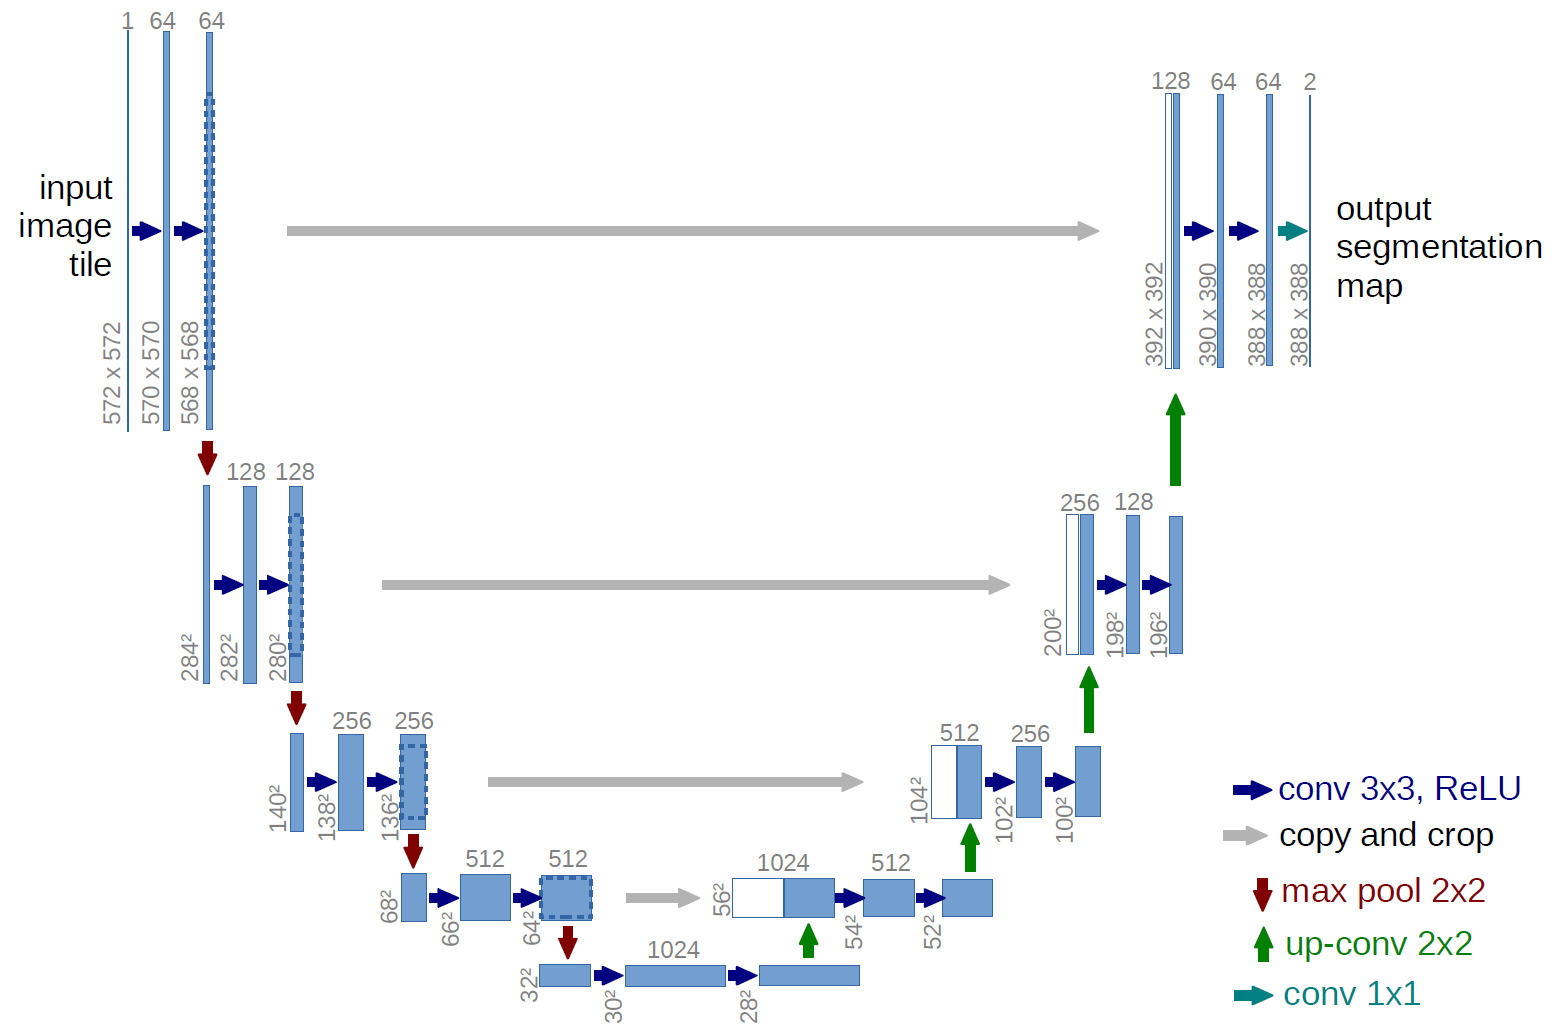

In [ ]:
# Импортируем вспомогательные функции и картинку с примером UNet
!wget --quiet --show-progress "https://raw.githubusercontent.com/mryab/dl-hse-ami/master/week06_vision/UNet.png"

# from utils import WeizmannHorsesDataset, show_sample
from PIL import Image
from IPython.display import display

display(Image.open("UNet.png"))



### Датасет Weizmann Horses

Мы будем использовать датасет фотографий лошадей с разметкой «лошадь / фон».

Ниже — код для загрузки датасета (предполагается, что архив скачан и распакован; в Colab можно раскомментировать `wget`).


In [ ]:
!git clone https://github.com/rooshenas/horses_dataset
!git clone https://github.com/octopanya/dl_hw

fatal: destination path 'horses_dataset' already exists and is not an empty directory.
fatal: destination path 'dl_hw' already exists and is not an empty directory.


In [ ]:
import sys
sys.path.append('/content/dl_hw')
from utils import WeizmannHorsesDataset, show_sample, plot_batch_with_results, plot_history, mean_accuracy, pixel_accuracy, mean_iou

Размер train-части датасета: 262
Форма изображения: torch.Size([3, 40, 60])
Форма маски: torch.Size([1, 40, 60])


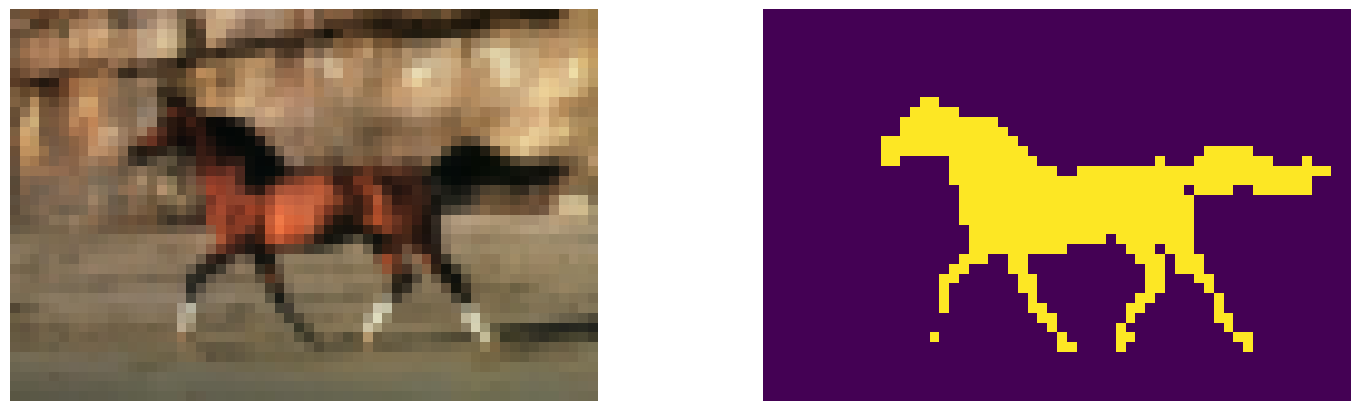

In [ ]:
data_path = "/content/horses_dataset"

dataset = WeizmannHorsesDataset(data_path, split="train", img_shape=(40, 60), color="images")
print("Размер train-части датасета:", len(dataset))

sample_image, sample_mask = dataset[0]
print("Форма изображения:", sample_image.shape)
print("Форма маски:", sample_mask.shape)

show_sample(dataset, 0)


## 2.2. Реализация UNet

Ниже приведена почти готовая реализация упрощённого UNet.  

In [ ]:
class ConvBlock(nn.Module): # синие стрелочки на картинке
    def __init__(self, input_ch, output_ch, kernel_size, block_depth):
        super().__init__()

        conv_list = []

        # Первая свертка (изменяет количество каналов)
        conv_list.extend([
            nn.Conv2d(input_ch, output_ch, kernel_size, padding=kernel_size//2),
            nn.BatchNorm2d(output_ch), # TODO: батчнорма
            nn.ReLU(inplace=True),     # TODO: функция активации
        ])

        # Последующие свертки (сохраняют количество каналов)
        for _ in range(block_depth - 1):
            conv_list.extend([
                nn.Conv2d(output_ch, output_ch, kernel_size, padding=kernel_size // 2), # TODO: свертка с таким же паддингом
                nn.BatchNorm2d(output_ch),                                              # TODO: батчнорма
                nn.ReLU(inplace=True),                                                  # TODO: функция активации
            ])

        self.conv_net = nn.Sequential(*conv_list) # TODO: создали из списка последовательность слоев

    def forward(self, x):
        return self.conv_net(x)  # TODO


class DownBlock(nn.Module): # красная стрелочка + синие после
    def __init__(self, input_ch, output_ch, kernel_size, block_depth):
        super().__init__()
        self.layers = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),     # TODO: пулингом уменьшение размера в 2 раза
            ConvBlock(input_ch, output_ch, kernel_size, block_depth)
        )

    def forward(self, x):
        return self.layers(x)   # TODO

Транспонированная свёртка в U-Net используется в декодере для **обучаемого увеличения разрешения** карт признаков.  
Слой `ConvTranspose2d` (или `Conv2DTranspose`) с ядром $2\times2$ и шагом 2 берёт входную карту и разворачивает каждый её пиксель в небольшой «патч» на выходе, так что высота и ширина увеличиваются в 2 раза. Перекрывающиеся области суммируются.  
В U-Net после такого апсемплинга результат конкатенируется с соответствующим слоем энкодера (skip-connection), чтобы совместить контекст и детали.

![image.png](https://camo.githubusercontent.com/0f6c5e4a3d351227b9cc187e3dc584de928c64400719abf9d70c6e80b99d288c/68747470733a2f2f6d69726f2e6d656469756d2e636f6d2f76322f726573697a653a6669743a313430302f312a59775676694269793271417030437753354344776d412e676966)

In [ ]:
class UpBlock(nn.Module): # зеленые стрелочки + синие после
    def __init__(self, input_ch, output_ch, kernel_size, block_depth):
        super().__init__()

        # Слой транспонированной свертки для увеличения размера
        self.upsample = nn.ConvTranspose2d(
            input_ch, output_ch, kernel_size=2, stride=2
        )

        # Сверточный блок после конкатенации
        # Умножаем output_ch на 2, потому что конкатенируем два тензора
        self.conv_block = ConvBlock(output_ch * 2, output_ch, kernel_size, block_depth)

    def forward(self, copied_input, lower_input):
        # Увеличиваем размер нижнего входа (из энкодера)
        lower_input = self.upsample(lower_input)

        # Проверяем и корректируем размеры если нужно
        # (может потребоваться из-за округления при пулинге)
        diffY = copied_input.size()[2] - lower_input.size()[2] # Разница по высоте
        diffX = copied_input.size()[3] - lower_input.size()[3] # Разница по ширине

        # Добавляем padding если размеры не совпадают
        lower_input = nn.functional.pad(lower_input,
                                       [diffX // 2, diffX - diffX // 2,
                                        diffY // 2, diffY - diffY // 2])

        # Объединяем пропущенный вход (skip connection) и увеличенный тензор
        x = torch.cat([copied_input, lower_input], dim=1) # Конкатенация по каналам

        return self.conv_block(x)

![image.png](attachment:71b9c80d-0c0a-4fa2-9fbc-192267e56f02.png)

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_classes, feature_levels_num, input_ch_size, hidden_ch_size, block_depth, kernel_size=3):
        super(UNet, self).__init__()
        self.input_block = ConvBlock(input_ch_size, hidden_ch_size, kernel_size, block_depth)
        self.down_blocks = []
        self.up_blocks = []
        self.feature_levels_num = feature_levels_num # Количество уровней сжатия/расширени

        # Строим энкодер (нисходящий путь) - сжатие
        cur_ch_num = hidden_ch_size
        for i in range(feature_levels_num):
            next_ch_num = cur_ch_num * 2
            down_block = DownBlock(cur_ch_num, next_ch_num, kernel_size, block_depth)
            self.down_blocks.append(down_block)
            cur_ch_num = next_ch_num # Обновляем текущее количество каналов для следующего уровня

        # Строим декодер (восходящий путь) - расширение
        for i in range(feature_levels_num):
            up_block = UpBlock(cur_ch_num, cur_ch_num // 2, kernel_size, block_depth)
            self.up_blocks.append(up_block)
            cur_ch_num = cur_ch_num // 2

        self.down_blocks = nn.ModuleList(self.down_blocks)
        self.up_blocks = nn.ModuleList(self.up_blocks)
        self.output_block = nn.Conv2d(hidden_ch_size, n_classes, kernel_size=1)

    def forward(self, x):
        # Сохраняем skip-connections для U-Net
        skip_connections = []

        # Начальная свертка
        x = self.input_block(x)
        skip_connections.append(x)

        # Путь энкодера: последовательное применение down-блоков
        for down_block in self.down_blocks:
            x = down_block(x)
            skip_connections.append(x)

        # Путь декодера: применяем up-блоки в обратном порядке
        for i, up_block in enumerate(self.up_blocks):
            # Берем соответствующий skip-connection из энкодера
            skip_connection = skip_connections[-(i + 2)]
            x = up_block(skip_connection, x)

        # Финальное преобразование к количеству классов
        return self.output_block(x)


## 2.3. Обучение UNet на задаче сегментации

Мы будем использовать:

- функцию потерь `CrossEntropyLoss` по пикселям,
- простую метрику Pixel Accuracy (какая доля пикселей угадана правильно), чтобы получать интерпретируемое качество обучения (а то что там значит эта кросс-энтропия:-)

In [ ]:
from tqdm.notebook import tqdm

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    model.train()  # TODO: модель в режим обучения
    loss_fn = nn.CrossEntropyLoss() # TODO
    for batch_num, (x_batch, y_batch) in tqdm(enumerate(train_loader), total=len(train_loader)): # TODO: итерируйтесь по обучающим данным с progress bar и подсчетом номера батча:
        # TODO: все переводим на устройство
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        prediction = model(x_batch) # TODO: предсказания модели

        # Проверяем размеры предсказания и маски
        if prediction.shape[2:] != y_batch.shape[2:]:
            # Изменяем размер предсказания под маску если нужно
            prediction = torch.nn.functional.interpolate(
                prediction,
                size=y_batch.shape[2:],
                mode='bilinear',
                align_corners=False
            )

        # target для CE: (B, H, W) с int64
        target = y_batch.squeeze(1).long()
        loss = loss_fn(prediction, target) # TODO
        optimizer.zero_grad()  # TODO: delete old grads
        loss.backward()        # TODO: backprop
        optimizer.step()       # TODO: update weights

        loss_log.append(loss.item())
    return loss_log

def test(model, test_loader, train_loader):
    history = defaultdict(list)
    model.eval()  # TODO: модель в режим тестирования
    loss_fn = nn.CrossEntropyLoss() # TODO
    with torch.no_grad(): # TODO: выключаем градиенты внутри блока
        # Validation
        for batch_num, (x_batch, y_batch) in tqdm(enumerate(test_loader), total=len(test_loader)): # TODO: итерируйтесь по тестовым данным с progress bar и подсчетом номера батча batch_num:
            # TODO: все переводим на устройство
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch) # TODO: предсказания модели

            # Изменяем размер предсказания если нужно
            if pred.shape[2:] != y_batch.shape[2:]:
                pred = torch.nn.functional.interpolate(
                    pred,
                    size=y_batch.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )

            target = y_batch.squeeze(1).long()
            ce_loss = loss_fn(pred, target).item() # TODO: функция потерь на тесте
            pred_labels = torch.argmax(pred, dim=1)

            # здесь подсчет Pixel accuracy
            iou_sum = 0
            pixel_acc_sum = 0
            mean_acc_sum = 0
            for i in range(x_batch.shape[0]):
                iou_sum += mean_iou(pred_labels[i].cpu(), y_batch[i].cpu().squeeze(0))
                pixel_acc_sum += pixel_accuracy(pred_labels[i].cpu(), y_batch[i].cpu().squeeze(0))
                mean_acc_sum += mean_accuracy(pred_labels[i].cpu(), y_batch[i].cpu().squeeze(0))

            history["loss_val"].append(ce_loss)
            history["iou_val"].append(iou_sum / x_batch.shape[0])
            history["pixel_acc_val"].append(pixel_acc_sum / x_batch.shape[0])
            history["mean_acc_val"].append(mean_acc_sum / x_batch.shape[0])

            if batch_num == 0:
                plot_batch_with_results(x_batch.cpu(), y_batch.cpu(), pred_labels.cpu())

        # Training metrics
        for batch_num, (x_batch, y_batch) in tqdm(enumerate(train_loader), total=len(train_loader)): # TODO: итерируйтесь по обучающим данным с progress bar и подсчетом номера батча batch_num:
            # TODO: все переводим на устройство
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch) # TODO: предсказания модели

            if pred.shape[2:] != y_batch.shape[2:]:
                pred = torch.nn.functional.interpolate(
                    pred,
                    size=y_batch.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )

            pred_labels = torch.argmax(pred, dim=1) # TODO: предсказанные метки для каждого пикселя (максимальный скор по пикселю)
            iou_sum = 0
            pixel_acc_sum = 0
            mean_acc_sum = 0

            for i in range(x_batch.shape[0]):
                iou_sum += mean_iou(pred_labels[i].cpu(), y_batch[i].cpu().squeeze(0))
                pixel_acc_sum += pixel_accuracy(pred_labels[i].cpu(), y_batch[i].cpu().squeeze(0))
                mean_acc_sum += mean_accuracy(pred_labels[i].cpu(), y_batch[i].cpu().squeeze(0))

            history["iou_train"].append(iou_sum / x_batch.shape[0])
            history["pixel_acc_train"].append(pixel_acc_sum / x_batch.shape[0])
            history["mean_acc_train"].append(mean_acc_sum / x_batch.shape[0])

    return history

def train_procedure(model, opt, n_epochs, train_loader, test_loader, scheduler):
    history = defaultdict(list)

    for epoch in range(n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")

        train_loss = train_epoch(model, opt, train_loader)
        test_history = test(model, test_loader, train_loader)

        history["loss_train"].extend(train_loss)
        history["loss_val"].append(np.mean(test_history["loss_val"]))

        for key in test_history:
            if key != "loss_val":
                history[key].append(np.mean(test_history[key]))

        # Вывод метрик
        print(f"Epoch {epoch+1}:")
        print(f"  Train Loss: {np.mean(train_loss):.4f}")
        print(f"  Val Loss: {history['loss_val'][-1]:.4f}")
        print(f"  Val IoU: {history['iou_val'][-1]:.4f}")
        print(f"  Val Pixel Acc: {history['pixel_acc_val'][-1]:.4f}")
        print(f"  Val Mean Acc: {history['mean_acc_val'][-1]:.4f}")
        print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6f}")

        scheduler.step()

        # Визуализация истории обучения
        plot_history(history)

def custom_collate(batch):
    x_batch = []
    y_batch = []

    for x, y in batch:
        # Приводим все изображения к 3 каналам
        if x.shape[0] == 1:
            x = x.repeat(3, 1, 1)  # grayscale -> RGB
        elif x.shape[0] == 4:
            x = x[:3]  # RGBA -> RGB

        if y.dim() == 2:
            y = y.unsqueeze(0)  # (H, W) -> (1, H, W)

        x_batch.append(x)
        y_batch.append(y)

    x_batch = torch.stack(x_batch)
    y_batch = torch.stack(y_batch)

    return x_batch, y_batch

In [ ]:
# Параметры
n_classes = 2
shape = (40, 60)
input_ch_size = 3
hidden_ch_size = 32
feature_levels_num = 3
block_depth = 2

batch_size = 8
n_epochs = 25 # можно изменить на 5-10, но лучше оставить так
lr = 0.001
lr_step = 10
lr_gamma = 0.5

Приступаем непосредственно к обучению:

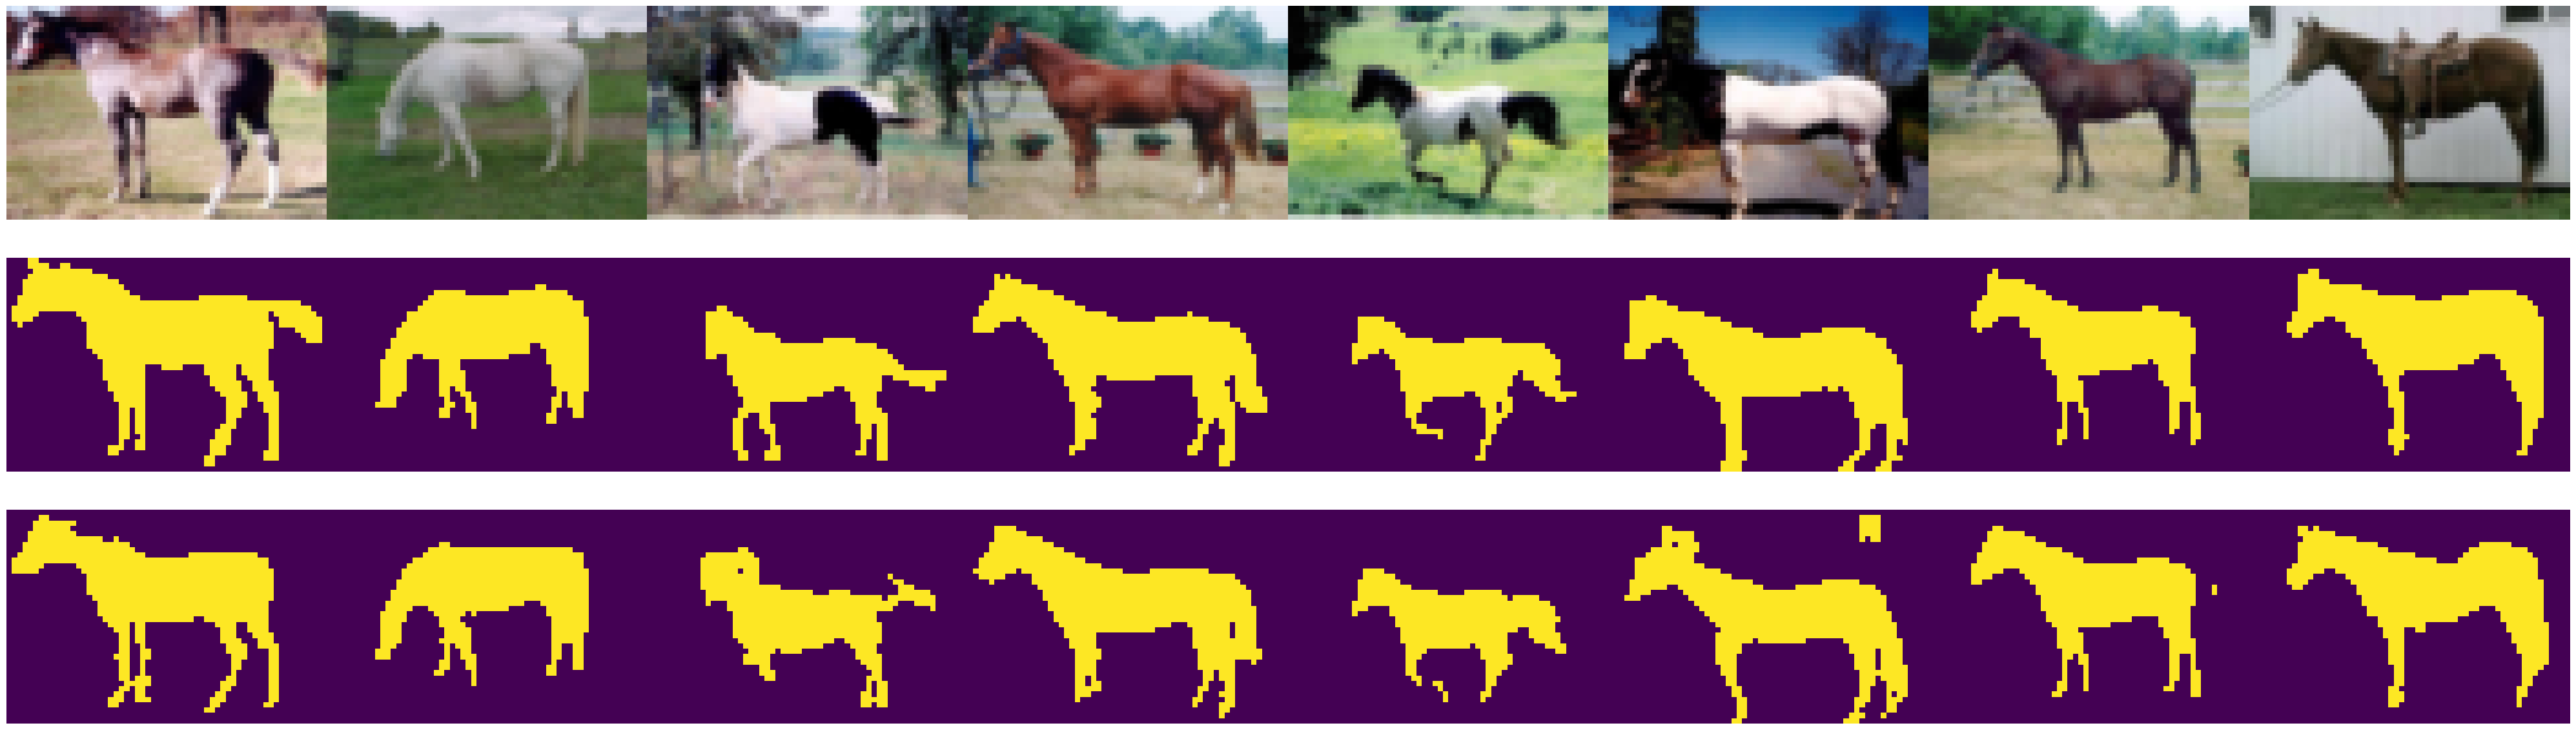

  0%|          | 0/33 [00:00<?, ?it/s]

Epoch 25:
  Train Loss: 0.0407
  Val Loss: 0.1128
  Val IoU: 0.8967
  Val Pixel Acc: 0.9614
  Val Mean Acc: 0.9510
  Learning Rate: 0.000250


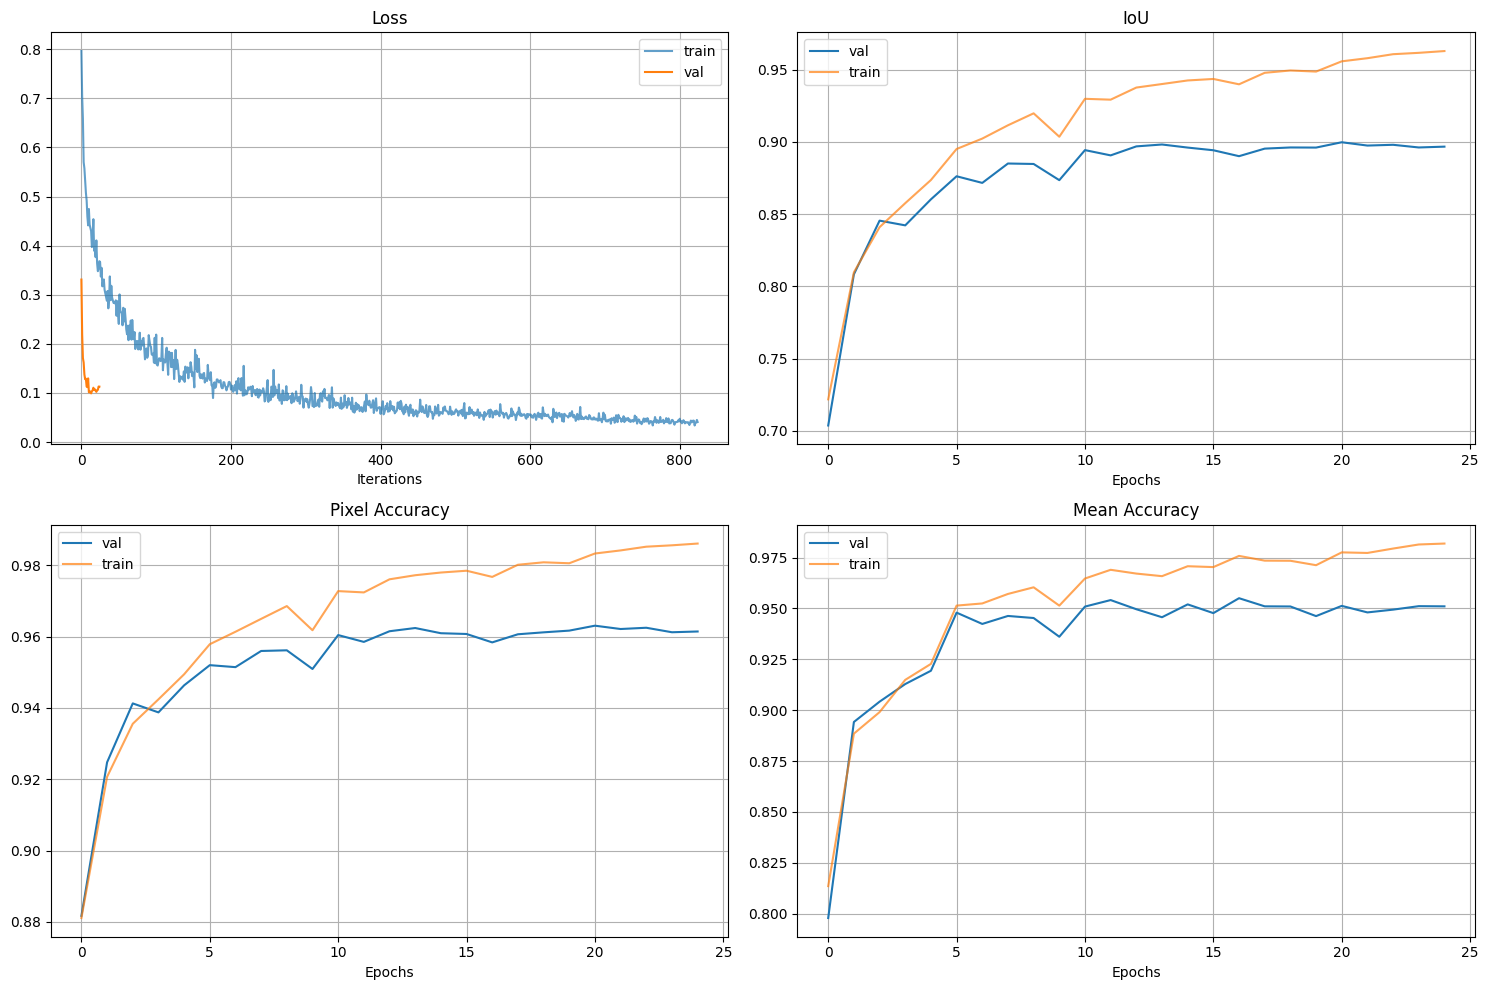

In [ ]:
train_dataset = WeizmannHorsesDataset(root=data_path, split="train", img_shape = shape)
test_dataset = WeizmannHorsesDataset(root=data_path, split="val", img_shape = shape)

train_loader = torch.utils.data.DataLoader(
    train_dataset,              # TODO: датасет
    batch_size=batch_size,      # TODO: размер батча
    shuffle=True,               # TODO: shuffle
    collate_fn=custom_collate
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=custom_collate
)

# Модель и оптимизатор
model = UNet(
    n_classes=n_classes,
    feature_levels_num=feature_levels_num,
    input_ch_size=input_ch_size,
    hidden_ch_size=hidden_ch_size,
    block_depth=block_depth
).to(device)                                      # TODO
opt = torch.optim.Adam(model.parameters(), lr=lr) # TODO
scheduler = torch.optim.lr_scheduler.StepLR(
    opt, step_size=lr_step, gamma=lr_gamma
)                                                 # TODO

# Запуск обучения
train_procedure(model, opt, n_epochs, train_loader, test_loader, scheduler=scheduler)

Теперь визуализируем результаты:

Визуализация результатов на валидационном наборе:


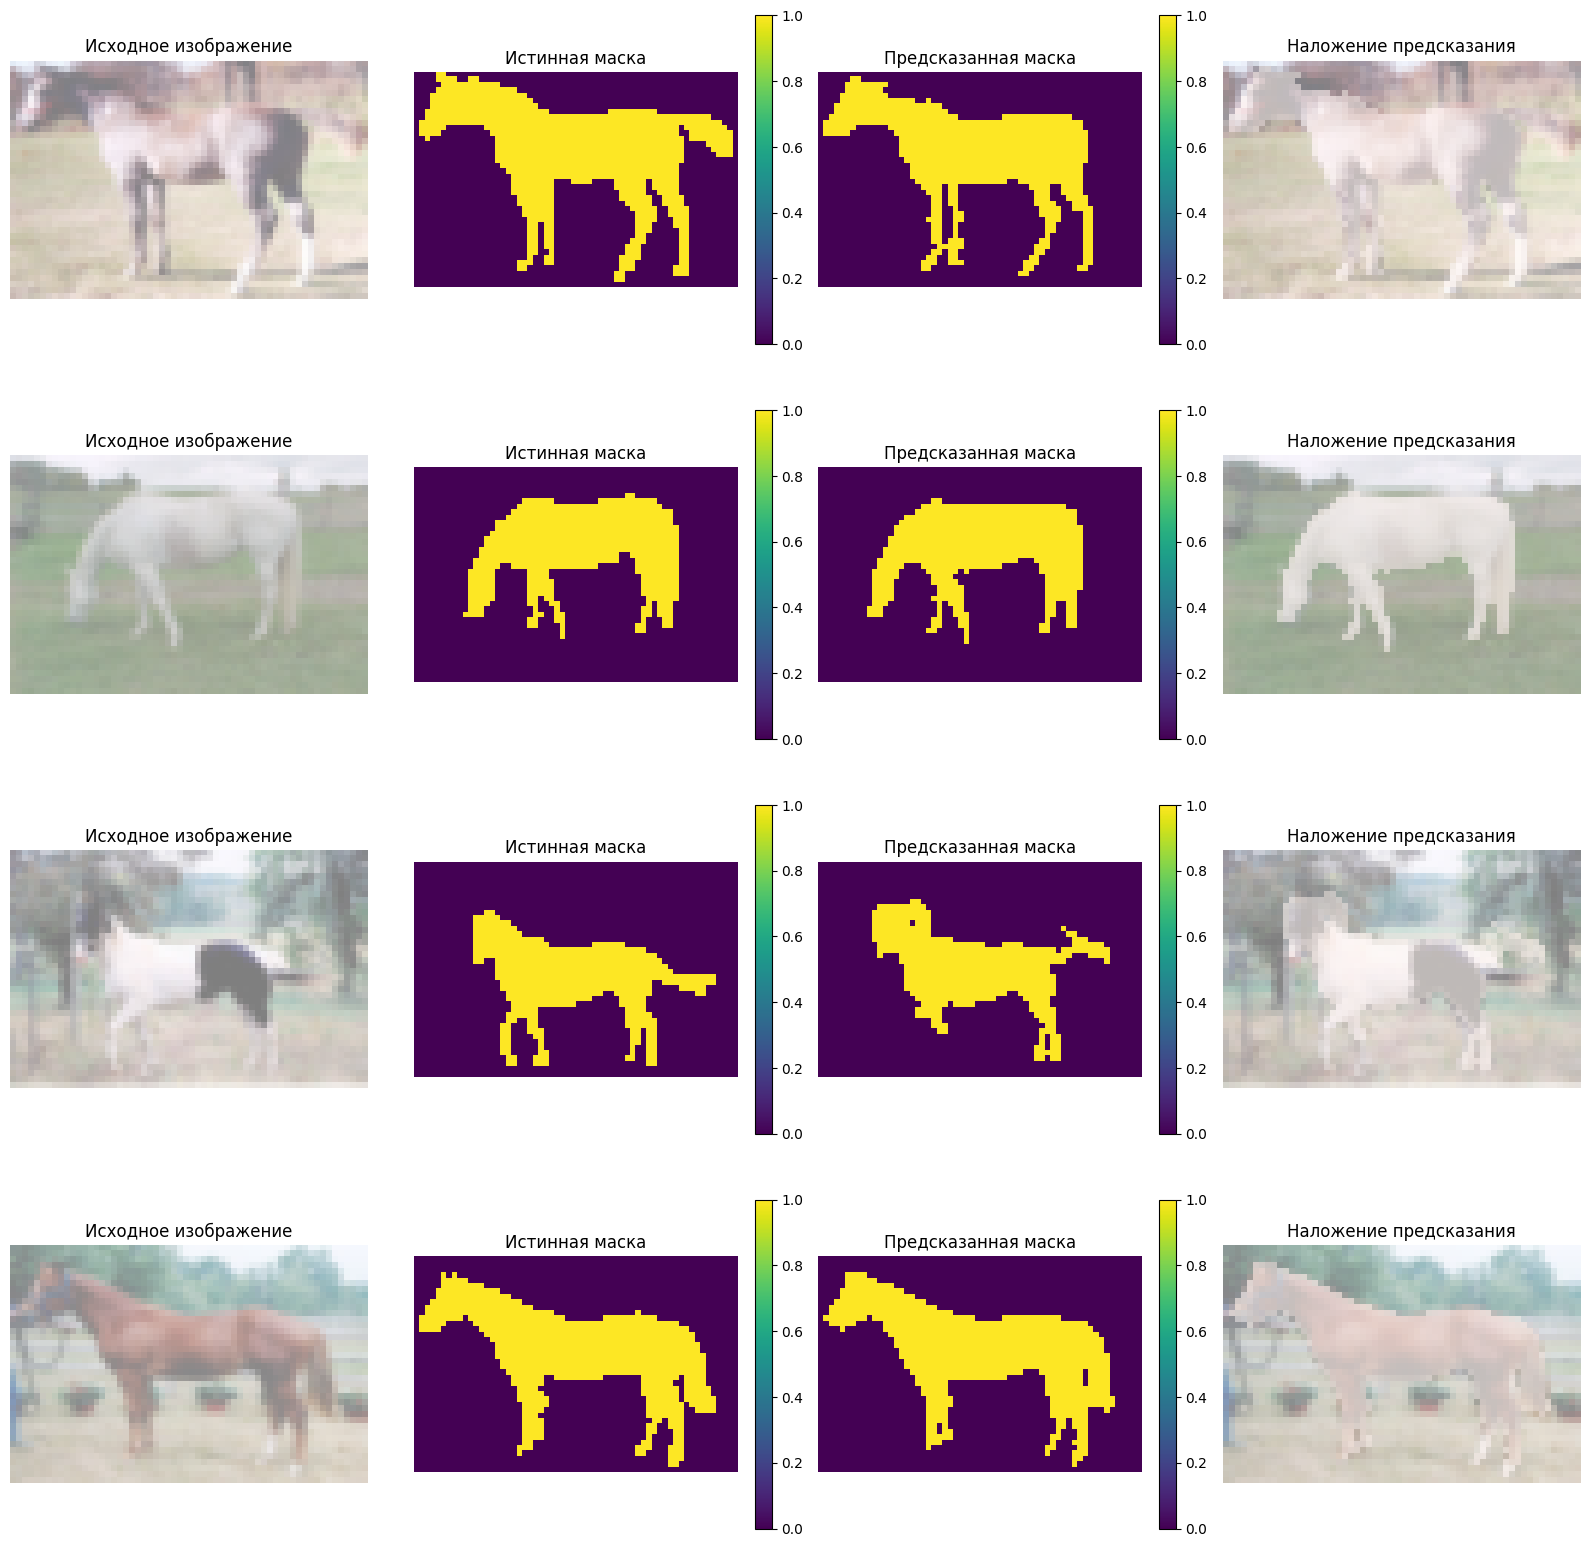

Метрики для батча (первые 4 примеров):
Средний IoU: 0.8814
Средняя Pixel Accuracy: 0.9508
Классы в истинных масках: [0 1]
Классы в предсказаниях: [0 1]


In [ ]:
def visualize_segmentation_results(model, data_loader, num_samples=4, device='cpu'):
    model.eval()

    # Получаем один батч данных
    imgs, masks = next(iter(data_loader))
    imgs = imgs.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

    # Перемещаем на CPU для визуализации
    imgs_np = imgs.cpu().numpy()
    masks_np = masks.cpu().numpy()
    preds_np = preds.cpu().numpy()

    n_show = min(num_samples, imgs_np.shape[0])
    fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))

    if n_show == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_show):
        # Исходное изображение
        img_display = np.transpose(imgs_np[i] / 2 + 0.5, (1, 2, 0))
        # Обрезаем значения до [0, 1] для корректного отображения
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title("Исходное изображение")
        axes[i, 0].axis("off")

        # Истинная маска
        true_mask = masks_np[i].squeeze()  # убираем dimension каналов если есть
        im_true = axes[i, 1].imshow(true_mask, cmap='viridis')
        axes[i, 1].set_title("Истинная маска")
        axes[i, 1].axis("off")
        plt.colorbar(im_true, ax=axes[i, 1], fraction=0.046)

        # Предсказанная маска
        pred_mask = preds_np[i].squeeze()
        im_pred = axes[i, 2].imshow(pred_mask, cmap='viridis')
        axes[i, 2].set_title("Предсказанная маска")
        axes[i, 2].axis("off")
        plt.colorbar(im_pred, ax=axes[i, 2], fraction=0.046)

        # Наложение предсказания на изображение
        axes[i, 3].imshow(img_display)
        # Наложение маски с прозрачностью
        overlay = np.ma.masked_where(pred_mask == 0, pred_mask)
        axes[i, 3].imshow(overlay, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title("Наложение предсказания")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

    # Вычисляем метрики для этого батча
    iou_batch = []
    pixel_acc_batch = []

    for i in range(n_show):
        true_mask = torch.tensor(masks_np[i].squeeze())
        pred_mask = torch.tensor(preds_np[i].squeeze())

        iou_batch.append(mean_iou(pred_mask, true_mask))
        pixel_acc_batch.append(pixel_accuracy(pred_mask, true_mask))

    print(f"Метрики для батча (первые {n_show} примеров):")
    print(f"Средний IoU: {np.mean(iou_batch):.4f}")
    print(f"Средняя Pixel Accuracy: {np.mean(pixel_acc_batch):.4f}")
    print(f"Классы в истинных масках: {np.unique(masks_np[:n_show])}")
    print(f"Классы в предсказаниях: {np.unique(preds_np[:n_show])}")



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Визуализация результатов
print("Визуализация результатов на валидационном наборе:")
visualize_segmentation_results(model, test_loader, num_samples=4, device=device)


### Вопрос 5. Чем сегментация отличается от классификации?

1. В чём принципиальное отличие задачи **сегментации** от задачи **классификации**?
2. Как именно работает **UNet**? Почему хотим вернуть изначальный размер изображения?
3. Почему такая архитектура популярна? Где она еще используется?
4. Чем удобно использовать UNet‑подобные архитектуры для сегментации?

**Ответ LLMки:**  

## 1) Чем сегментация отличается от классификации?

**Классификация** выдаёт **одну метку на всё изображение** (например: “лошадь” / “не лошадь”).
**Сегментация** выдаёт **метку для каждого пикселя**: к какому классу он относится (например: “фон” или “лошадь”).
То есть сегментация — это задача “понимания картинки на уровне пикселей”.

## 2) Как работает UNet и зачем возвращать исходный размер?

UNet состоит из двух частей:

* **Encoder (downsampling)**: последовательность свёрток + пуллингов, которая уменьшает пространственное разрешение и извлекает всё более абстрактные признаки (контекст).
* **Decoder (upsampling)**: последовательность апсемплингов (транспонированные свёртки или интерполяция) + свёрток, которая восстанавливает разрешение и **предсказывает класс для каждого пикселя**.
* **Skip-connections**: на каждом уровне декодер получает “детали” из соответствующего слоя энкодера (конкатенация по каналам). Это помогает не потерять границы и мелкие структуры.

Исходный размер нужно вернуть, потому что выход сегментации — это **маска того же размера, что и входное изображение**, чтобы можно было “разметить” каждый пиксель.

## 3) Почему архитектура популярна и где ещё используется?

UNet популярна потому что:

* сочетает **контекст** (из глубины энкодера) и **точные детали** (через skip-connections),
* хорошо работает даже на относительно небольших датасетах,
* проста в реализации и обучении, даёт сильный baseline.

Где используется:

* **медицинская сегментация** (органы, опухоли на МРТ/КТ),
* сегментация в **робототехнике** и **автопилоте** (дорога/разметка/объекты),
* **спутниковые снимки** (дороги, здания, поля),
* любые задачи “выделения объекта/областей” на изображении.

## 4) Чем удобны UNet-подобные архитектуры для сегментации?

* Они дают **пиксельные предсказания** сразу (dense prediction).
* Skip-connections помогают **точно восстанавливать границы объекта**.
* Можно легко менять глубину/ширину сети под задачу и железо.
* Хорошо работают как “универсальный шаблон”: UNet-подобные идеи лежат в основе многих современных сегментационных моделей (включая более продвинутые варианты и гибриды).


**Ваш ответ:**

1. Задача классификации дает один ответ на все изображение: модель смотрит на картинку целиком и решает, к какому классу она относится - например, «на картинке есть лошадь» или «собака». В задаче сегментации нужно гораздо более подробное решение: модель должна присвоить класс каждому пикселю - «лошадь / фон» или несколько классов, если их больше. То есть классификация отвечает на вопрос «что?», а сегментация - «что и где именно», восстанавливая форму и границы объектов на изображении.

2. UNet решает эту задачу с помощью двух симметричных “веток”: энкодера и декодера. Энкодер (нисходящий путь) последовательно уменьшает размер изображения с помощью сверток и пуллинга, извлекая все более абстрактные признаки. Декодер (восходящий путь) делает обратное: по этим признакам, с помощью апсемплинга и транспонированных сверток, восстанавливает пространственное разрешение. Ключевая идея - skip-connections: на каждом уровне признаки из энкодера “перекидываются” в декодер и конкатенируются, чтобы совмещать контекст и тонкие детали. Именно поэтому на выходе мы хотим получить карту классов того же размера, что и входное изображение: нам нужна маска на уровне пикселей, а не усреднённый ответ.

3. Такая архитектура стала популярной, потому что удачно балансирует качество и простоту. UNet хорошо работает даже на сравнительно небольших датасетах, умеет восстанавливать точные границы объектов, а строится из стандартных блоков - свертки, BatchNorm, пуллинги, апсемплинг. Поэтому ее активно используют в медицине (сегментация органов и опухолей на КТ и МРТ), в обработке спутниковых снимков (дороги, здания, поля), в задачах автономного вождения и робототехники (выделение дороги, разметки, пешеходов) и вообще в любой задаче, где важно “раскрасить” картинку по классам.

4. UNet-подобные архитектуры удобны тем, что они из коробки решают именно ту задачу, которая нужна при сегментации: на вход подается изображение, на выходе получаешь карту классов того же размера. Skip-connections позволяют одновременно учитывать и глобальный контекст, и локальные мелкие детали, поэтому маски получаются достаточно точными. Схему легко адаптировать под конкретную задачу: можно менять количество уровней, число каналов, добавлять регуляризацию, использовать предобученные энкодеры. В результате UNet становится универсальным, понятным и расширяемым “шаблоном” для большинства задач пиксельной сегментации.



## 2.4. Детекция объектов с помощью YOLO (Ultralytics)

**Детекция** — это проверка: «какие объекты есть на картинке и где они находятся?»  
Результат — прямоугольники (bounding boxes) и классы внутри них.

Мы воспользуемся готовой реализацией **YOLOv8** от Ultralytics и предобученной моделью `yolov8n.pt`.

### YOLO: Краткий обзор

**YOLO (You Only Look Once)** — это семейство нейросетей для детекции объектов (Object Detection) в реальном времени. В отличие от старых подходов, которые сканировали картинку кусочками, YOLO «смотрит один раз» на всё изображение целиком и сразу выдаёт результат.

#### Как это работает:
1.  **Сетка (Grid):** Изображение разбивается на сетку, например, $(S \times S)$. Каждая ячейка отвечает за предсказание объекта, если его центр попадает в эту ячейку.
2.  **Один проход (Single Shot):** Нейросеть (обычно на базе сверточной модели) за один прогон предсказывает для каждой ячейки:
    *   Координаты **Bounding Box** (рамки) объекта.
    *   **Вероятность** того, что в ячейке есть объект.
    *   **Класс** объекта (человек, машина, кот).
3.  **Фильтрация:** Поскольку многие ячейки могут предсказать один и тот же объект, используется алгоритм **NMS (Non-Maximum Suppression)**, который убирает дублирующиеся рамки, оставляя только самую точную.

![image.png](attachment:4fd3c37f-4964-4fe8-8ca9-6ea70cb15606.png)

In [ ]:
# Установка ultralytics (может занять немного времени)
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.0 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


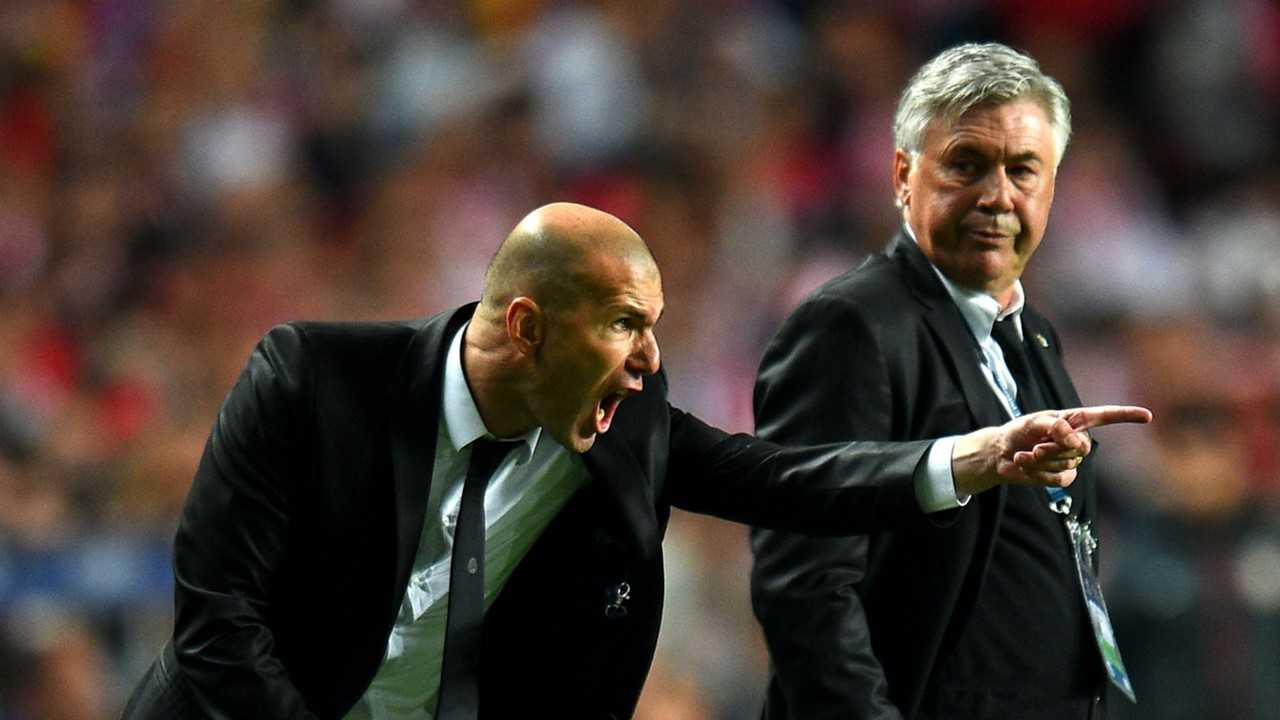


0: 384x640 2 persons, 1 tie, 43.6ms
Speed: 25.6ms preprocess, 43.6ms inference, 6.1ms postprocess per image at shape (1, 3, 384, 640)


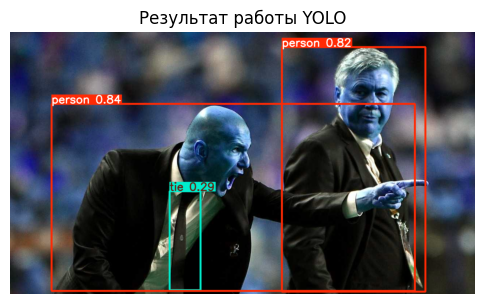

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO

# Скачаем любую картинку (можете попробовать свои)
url = "https://ultralytics.com/images/zidane.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

display(img)

# Загрузим предобученную модель
yolo_model = YOLO("yolov8n.pt")

results = yolo_model(img)

# Отобразим результат с нарисованными боксами
res_img = results[0].plot()  # numpy array
plt.figure(figsize=(6, 6))
plt.imshow(res_img)
plt.axis("off")
plt.title("Результат работы YOLO")
plt.show()



### Вопрос 6. Детекция vs сегментация

1. В чём разница между результатом **YOLO** и результатом **UNet**?
2. В каких HR‑задачах и организацией работы сотрудников в целом, на ваш взгляд, детекция объектов может быть полезна?

**Ответ LLMки:**  
**1) Разница между результатом YOLO и UNet**

* **YOLO (детекция)** возвращает список объектов на изображении: *класс + координаты прямоугольной рамки (bounding box) + confidence*. То есть отвечает на вопрос **«что есть на картинке и где примерно находится»**.
* **UNet (сегментация)** возвращает **пиксельную маску**: для *каждого пикселя* предсказывается класс (фон/лошадь и т.п.). То есть отвечает на вопрос **«какие пиксели принадлежат объекту»**, давая точные границы.

Итого: детекция — грубая локализация прямоугольником, сегментация — точное выделение формы объекта.


**2) Где детекция может быть полезна в HR и организации работы сотрудников**

Несколько реалистичных примеров (при корректном согласии сотрудников и соблюдении приватности):

* **Контроль средств индивидуальной защиты (PPE)** на производстве: каска/жилет/очки — детекция помогает автоматически замечать нарушения техники безопасности.
* **Оценка загруженности рабочих зон** (склад, офис, переговорки): детекция людей позволяет строить агрегированную статистику занятости помещений и оптимизировать пространство/расписание.
* **Логистика и безопасность**: детекция опасных ситуаций (человек в запретной зоне, толпа у выхода, блокировка проходов).
* **Инвентаризация и контроль процессов**: распознавание наличия нужных объектов на рабочем месте (инструменты, оборудование) для соблюдения регламентов.
* **Аналитика очередей/потоков** (например, на проходной): оценка времени ожидания и планирование смен/ресурсов.

Важно: такие применения требуют прозрачных правил, минимизации данных (лучше хранить агрегаты, а не видео), а также юридического и этического согласования.


**Ваш ответ:**
1. Результат YOLO и результат UNet отличаются “гранулярностью”. YOLO решает задачу детекции: находит на изображении объекты, рисует вокруг них прямоугольные боксы и подписывает классы (“человек”, “машина” и т.п.). То есть на выходе - набор прямоугольников с координатами и метками классов. UNet решает задачу сегментации: она не рисует рамки, а красит каждый пиксель в соответствующий класс, в результате получается маска, которая дает точную форму объекта (лошадь/фон, дороги/здания/деревья и т.д.). Грубо: YOLO говорит “вот тут человек”, UNet - “вот ровно область, где находится человек, пиксель за пикселем”.

2. Детекция объектов может быть полезна в HR-контексте в задачах, где важна организация пространства и процессов, а не конкретные лица. Например: контроль загрузки переговорок и рабочих зон (подсчет людей в комнате, оценка плотности), мониторинг соблюдения техники безопасности (определение наличия каски/жилета в цехе или на стройке), анализ использования офисной инфраструктуры (как часто и какие зоны используются, есть ли перегруженные участки), оценка потоков людей при эвакуационных тренингах. Все это можно делать анонимно - модель видит “человек/объект”, а HR-аналитик получает агрегированные показатели: где тесно, где недогружено, где нарушаются регламенты, и на основе этого может менять планировку, процессы или графики работы.


## 2.5. Segment Anything (SAM) и CLIP: «модели из коробки»

Современные модели позволяют делать много «из коробки», почти без обучения:

- **SAM (Segment Anything Model)** — модель от Meta, которая умеет сегментировать «что угодно» по точке/прямоугольнику/тексту.
- **CLIP** — модель от OpenAI, которая связывает изображения и текст (можно задавать подписи к картинкам в свободной форме).

Ниже — минимальные примеры запуска. Они могут потребовать больше видеопамяти, поэтому в Colab желательно выбрать GPU.

### SAM: Краткий обзор

**SAM (Segment Anything Model)** — это фундаментальная модель (Foundation Model) для сегментации изображений от Meta AI. В отличие от классических сетей (типа U-Net), которые ищут конкретные классы объектов (кот, машина), SAM спроектирована для сегментации **любого** объекта на изображении по внешнему запросу (промпту), даже если модель никогда не видела такой объект при обучении (Zero-Shot Transfer).

#### Как это работает:
1.  **Image Encoder (ViT):** Тяжелый энкодер (Vision Transformer) один раз обрабатывает изображение и создает его мощное векторное представление (эмбеддинг). Этот процесс самый ресурсоемкий, но выполняется лишь один раз на картинку.
2.  **Prompt Encoder:** Легковесный модуль, который кодирует входные подсказки пользователя:
    *   Точки (клики мышкой по объекту).
    *   Рамки (bounding box).
    *   Плотные маски или текст.
3.  **Mask Decoder:** Легкий декодер, который объединяет эмбеддинг картинки и эмбеддинг подсказки. Он почти мгновенно (за ~50 мс) генерирует маску сегментации для указанного объекта. Если запрос неоднозначный (например, клик на рубашку может означать «рубашка» или «человек целиком»), SAM выдает сразу несколько вариантов масок с оценками уверенности (IoU score).

![image.png](attachment:42c50446-88de-4a39-ba9b-484af5048002.png)

In [ ]:
# ВНИМАНИЕ: запуск SAM может потребовать много памяти и времени.
# Если среда не справляется, можно просто ПРОЧИТАТЬ код и ответить на вопросы ниже.

!pip install -q "git+https://github.com/facebookresearch/segment-anything.git" opencv-python

  Preparing metadata (setup.py) ... done


In [ ]:
# Скачаем чекпойнт (для Colab; при локальном использовании скачайте заранее)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

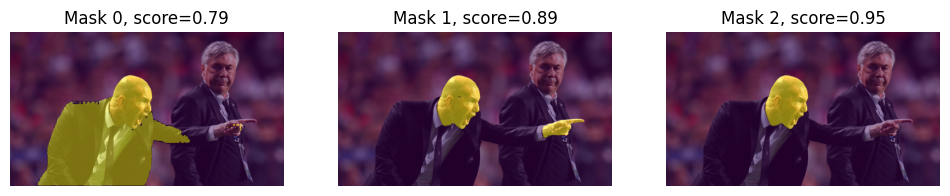

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
import urllib.request
import torch

# Загрузка изображения по URL
url = "https://ultralytics.com/images/zidane.jpg"

# Скачиваем изображение и преобразуем в numpy array
resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

predictor = SamPredictor(sam)
predictor.set_image(image)

# Укажем точку на изображении (например, центр)
h, w, _ = image.shape
input_point = np.array([[w // 2, h // 2]])
input_label = np.array([1])  # 1 = foreground

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

plt.figure(figsize=(12, 4))
for i, mask in enumerate(masks):
    plt.subplot(1, 3, i+1)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.5)
    plt.axis("off")
    plt.title(f"Mask {i}, score={scores[i]:.2f}")
plt.show()


### CLIP: Краткий обзор

**CLIP (Contrastive Language-Image Pre-training)** — это мультимодальная нейросеть от OpenAI, которая учится понимать связь между картинками и текстом. Она строит **единое векторное пространство** (embedding space), где похожие по смыслу изображения и текстовые описания находятся близко друг к другу (косинусная близость стремится к 1).

![image.png](attachment:a5ac4d86-a0ff-40e7-92ad-ce85a3654cb4.png)

#### Как это работает:
1. **Два энкодера:** Один для картинок (Vision Transformer или ResNet), другой для текста (Text Transformer).
2. **Совместное обучение:** Модель учится на парах *(картинка, текст)* сближать векторы "правильных" пар и отдалять "неправильные" (Contrastive Loss).
3. **Результат:** Ты можешь взять картинку и текст, превратить их в векторы и математически проверить, насколько этот текст описывает эту картинку.

![image.png](attachment:479c9343-fa56-44f9-9616-4bbd076ed920.png)
*Максимизируем произведения векторов на диагонали, минимизируем везде кроме диагонали*

Пример использования CLIP из библиотеки transformers:

In [ ]:
!pip install -q transformers

In [ ]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Возьмём ту же картинку с Зиданом
texts = ["a soccer player", "a dog", "a group of people", "a car on the road"]

inputs = clip_processor(text=texts, images=img, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = clip_model(**inputs)
    logits_per_image = outputs.logits_per_image  # (1, N_texts)
    probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

for text, p in zip(texts, probs):
    print(f"{text:20s} -> {p:.3f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

a soccer player      -> 0.663
a dog                -> 0.030
a group of people    -> 0.292
a car on the road    -> 0.016



### Вопрос 7. Интерактивные и «умные» модели

1. Чем **SAM** отличается от UNet с точки зрения использования (подсказка: SAM не нужно обучать под каждую задачу)?
2. Чем **CLIP** отличается от обычной классификационной модели (подсказка: можно использовать свободный текст)?
3. Про работу **CLIP**: как произведение и близость эмбеддингов связаны?
4. Как такие модели могут быть полезны в HR‑контексте?

**Ответ LLMки:**  
1. **SAM vs UNet (по использованию)**

* **UNet** обычно нужно **обучать под конкретные классы и датасет** (например, “лошадь/фон”). Без обучения на вашей разметке она не будет “знать”, что сегментировать.
* **SAM** — модель “из коробки”: её **не надо дообучать под каждый новый объект**. Вместо этого ей дают **промпт** (точку/несколько точек/рамку), и она сегментирует выбранный объект даже в новых доменах (zero-shot). Это делает её интерактивной и универсальной.

2. **CLIP vs обычная классификация**

* Обычная классификационная модель предсказывает **только фиксированный набор классов**, заданный при обучении (“10 классов CIFAR10” и т.п.).
* **CLIP** сравнивает изображение с **любыми текстовыми описаниями**, которые вы зададите (free-form text). Поэтому его можно использовать в режиме **zero-shot classification**: просто написать несколько вариантов текста и выбрать самый похожий.

3. **Про эмбеддинги CLIP: произведение и близость**
   CLIP кодирует изображение и текст в векторы (эмбеддинги). Затем считается их “похожесть”. Обычно это:

* **скалярное произведение** (dot product) эмбеддингов,
* или **косинусная близость** (это dot product нормированных векторов).

Чем больше значение (ближе к 1 для cosine), тем **более семантически соответствует** текст изображению. В коде `logits_per_image` — это как раз такие “scores similarity”, а `softmax` превращает их в вероятности по выбранным текстам.

4. **Как SAM/CLIP могут быть полезны в HR-контексте**
   (при соблюдении приватности, согласий и минимизации данных)

* **SAM**: быстрое интерактивное выделение объектов на фото/видео (например, разметка данных для обучения внутренних моделей: выделить сотрудника/экипировку/зону). Это ускоряет подготовку датасетов и проверку качества.
* **CLIP**: “поиск по смыслу” в медиаконтенте — можно искать изображения/кадры по запросам вида “people wearing safety helmets”, “crowded hallway”, “training session”. Также удобно для быстрой первичной категоризации контента без ручной разметки.
* В целом такие модели полезны тем, что **снижают порог входа**: часть задач решается без долгого обучения моделей и без больших размеченных датасетов.

**Ваш ответ:**

1. UNet - это архитектура, которую обычно учат под конкретную задачу: есть свой датасет (например, “лошадь / фон”), мы тренируем модель, и дальше она умеет сегментировать только такие классы, на которых училась. SAM - это уже предобученная универсальная модель сегментации: ее не нужно дообучать под каждый новый класс или датасет, достаточно дать “подсказку” (клик по объекту, рамка, иногда текст), и она тут же выдаёт маску нужного объекта. То есть UNet - “под конкретный проект”, SAM - “один раз обучили, дальше используем из коробки для очень разных задач”.

2. Обычная модель классификации работает с фиксированным набором классов: мы заранее задаём список меток (“кот”, “собака”, “машина”), учим сеть, и она на выходе дает распределение по этим заранее заданным классам. CLIP работает иначе: он сопоставляет картинку и произвольный текст в общем векторном пространстве. Мы можем задать любой набор текстовых описаний (“человек за ноутбуком”, “командный митинг”, “пустой офис”), не переобучая модель, и выбрать то описание, чей текстовый эмбеддинг ближе всего к эмбеддингу картинки. То есть вместо жесткого списка классов мы получаем гибкий “поисковик по смыслу” между изображениями и свободным текстом.

3. И для текста, и для изображения CLIP строит векторы фиксированной длины - эмбеддинги. Во время обучения модель настраивается так, чтобы эмбеддинг “правильного” текста был максимально близок к эмбеддингу соответствующей картинки, а “неправильных” описаний - далеко. Близость обычно измеряется косинусным сходством (по сути - нормированное скалярное произведение векторов): чем больше произведение и чем меньше угол между векторами, тем выше вероятность, что этот текст хорошо описывает именно эту картинку. Когда мы считаем softmax по всем произведениям “картинка · текст_i”, получаем вероятности “насколько хорошо каждый текст подходит к изображению”.

4. Такие модели можно использовать как “умные инструменты” поверх визуальных данных без тяжелой ML-разработки. CLIP - для поиска и сортировки медиа: например, быстро находить в фотоархиве “командные мероприятия”, “офис в open space”, “производственный цех”, даже если файлы никак не размечены. SAM - для полуавтоматической разметки: быстро выделить на изображении рабочие зоны, средства защиты, оборудование, чтобы затем анализировать безопасность, использование пространства или условия труда. В совокупности это позволяет HR-аналитикам и специалистам по рабочей среде работать с визуальными данными “по смыслу”, не погружаясь глубоко в классическое обучение нейросетей.
Главное преимущество - **скорость и дешевизна внедрения**. Не нужно собирать данные и месяцами обучать модели. Можно быстро создавать прототипы и автоматизировать рутинные визуальные задачи.




## 2.7. (Опционально) Идея отслеживания объектов (CoTracker и др.)

Сегментация и детекция — это анализ **одного кадра**.  
Для видео часто важно отслеживать: «куда движется этот объект с течением времени?»

Существуют модели типа **CoTracker**, которые:

- принимают видео и несколько точек/объектов,
- отслеживают их движение на всех кадрах.

В рамках этого ДЗ достаточно:

1. Найти документацию / репозиторий CoTracker.
2. Понять на уровне идей, как решается задача отслеживания объектов.
3. Ответить на вопрос ниже (запускать модель не обязательно, это довольно тяжело для обычного ноутбука).

### Вопрос 8. Трекинг объектов

1. Чем задача **треккинга** отличается от простой детекции на каждом кадре по отдельности?
2. В каких задачах HR‑аналитики могли бы использовать трекинг?
3. Какой общий принцип работы модели CoTracker?

**Ответ LLMки:**  
1. **Чем трекинг отличается от детекции по кадрам?**
   Детекция “по кадрам” на каждом кадре независимо отвечает: *«что есть и где»* (боксы/классы), но **не говорит**, что найденный человек на кадре t — это тот же самый человек на кадре t+1.
   **Трекинг** добавляет **временную связность и идентичность**: он связывает объекты между кадрами, выдаёт **траектории/ID** и умеет переживать пропуски, смазывания, частичные перекрытия (окклюзии).

2. **Где HR-аналитика могла бы использовать трекинг?** (при согласии, минимизации данных и соблюдении приватности)

* **Безопасность труда**: отслеживание нахождения людей в опасных зонах, соблюдение маршрутов, пересечения с техникой/погрузчиками.
* **Загруженность пространств**: траектории потоков в офисе/складе/на проходной, анализ очередей, “узкие места” в планировке.
* **Организация процессов**: время прохождения этапов (например, перемещение между участками), выявление задержек и неэффективных маршрутов.
* **Косвенная оценка условий труда**: длительные статические позы/перемещения (для эргономики) — чаще лучше в виде агрегированных метрик, без персональных идентификаторов.

3. **Общий принцип работы CoTracker**
   CoTracker — это трекер, который отслеживает **точки (пиксели)** во времени: на вход подаётся видео и набор точек (например, клики по объекту), на выходе — их координаты на всех кадрах.
   Ключевая идея: он трекает точки **совместно**, используя взаимосвязи между ними (точки одного объекта обычно движутся согласованно). Это повышает устойчивость при окклюзиях и “пропаданиях” точек. Обычно внутри — извлечение признаков по кадрам + сопоставление по времени (корреляции/attention в трансформере) + уточнение траекторий.


**Ваш ответ:**
1. Если делать только детекцию, мы на каждом кадре отдельно получаем: “Вот здесь человек, вот там стул, вот тут ноутбук” - набор боксов без связи между кадрами. Трекинг же решает более сложную задачу: не только находит объекты, но и присваивает им устойчивые ID во времени, т.е. отвечает на вопрос: “вот ЭТОТ человек на 1-м кадре - тот же, что и на 2-м, 3-м, 50-м…”. То есть детекция отвечает “что и где на этом кадре?”, а трекинг - “как этот же объект движется по видео со временем?”.

2. В HR-задачах трекинг полезен там, где важно поведение или перемещение людей/объектов во времени, а не просто факт присутствия. Например: анализ использования офисного пространства (как сотрудники реально перемещаются по этажам, где образуются “пробки” и очереди), оценка времени ожидания в столовой или рецепции, соблюдение безопасных маршрутов на производстве, контроль нахождения людей в опасных зонах, а также исследование паттернов взаимодействия (как часто и где люди собираются группами, есть ли “узкие места” в логистике рабочих процессов). Все это можно использовать для улучшения эргономики, безопасности и эффективности рабочих пространств.

3. CoTracker - это модель для совместного трекинга множества точек/объектов во времени. На вход она получает видео и набор точек (или маленьких областей), которые нужно “проследить” по всем кадрам. Вместо того чтобы трекать каждую точку независимо, модель обрабатывает их совместно (отсюда Co), обычно с помощью архитектуры на основе трансформера: она смотрит на весь видеоклип и все точки сразу, учитывая как временной контекст (что происходило до и после), так и взаимосвязь между точками (например, части одного объекта движутся согласованно). На выходе CoTracker дает траектории этих точек по кадрам - по сути, “как именно все это двигалось” во времени.

**1. Ссылки:**
1. Репозиторий на GitHub: [Код](https://co-tracker.github.io/)
2. Описание [Документация](https://arxiv.org/abs/2307.07635)

**2. Идея задачи трекинга (object/point tracking) - простыми словами**

Вход: у нас есть видео (последовательность кадров) и несколько точек/областей, за которыми нужно “следить” (например, угол стола, рука человека, шлем и т.п.).

Общий взгляд на все сразу: модель не трекает каждую точку отдельно, а смотрит сразу на все видео и на все точки вместе. Для этого используют архитектуру вроде трансформера: она умеет учитывать и время (кадр 1 → 2 → 3…) и связи между точками (части одного объекта движутся согласованно).

Совместное внимание: модель учится понимать:

куда могла “переехать” точка на следующем кадре,

как движется объект в целом,

как изменяется фон/камера.
То есть она строит что-то вроде “карты движения” для всех точек разом.

Выход: для каждой точки на первом кадре CoTracker выдаёт её траекторию по всем кадрам - координаты, где эта точка находится в момент времени t. Так мы получаем устойчивое отслеживание объектов во времени, более надежное, чем просто детекция по одному кадру.


---
# Итоговые вопросы по всему домашнему заданию
*Можно повторяться, так как часть вопросов дублирует те, что задавались по ходу решения. Отработаем и закрепим ещё раз :)*

1. В чём основные различия между:
   - свёрточной сетью, обученной с нуля
   - предобученной моделью (ResNet) с transfer learning
   - большими open‑source моделями (YOLO, SAM, CLIP)?
   

2. Напишите 2–3 идеи мини‑проектов или задач в HR, где вы могли бы применить:
   - классификацию изображений
   - сегментацию или детекцию
   - открытые модели типа SAM/CLIP

**Ответ LLMки:**
## 1) Основные различия

### Свёрточная сеть, обученная с нуля

* **Вы сами учите всё с нуля**: и “простые” признаки (границы/текстуры), и более сложные.
* Нужны **данные + время + аккуратный тюнинг** (архитектура, регуляризация, scheduler), иначе легко получить переобучение/недообучение.
* Плюс: полный контроль и простота. Минус: обычно хуже качество при малом датасете.

### Предобученная модель (ResNet) + transfer learning

* “Тело” сети уже выучило **универсальные визуальные признаки** на большом датасете (ImageNet).
* Вы либо обучаете только “голову”, либо **fine-tune** часть/всю модель под свою задачу.
* Обычно даёт **лучшее качество и быстрее сходится** на небольших данных, чем обучение с нуля.

### Большие open-source модели (YOLO, SAM, CLIP)

* Это уже “модели из коробки”, часто **очень хорошо обученные заранее** и готовые решать широкий круг задач.
* **YOLO**: детекция (боксы+классы) — быстрый inference, удобно для “найти и посчитать”.
* **SAM**: универсальная сегментация по промпту (точка/рамка) — почти без обучения под задачу.
* **CLIP**: связывает текст и изображение — можно делать **zero-shot классификацию** и “поиск по описанию”.
* Плюс: минимум обучения и быстрый старт. Минус: требования к ресурсам, ограничения домена, вопросы приватности/этики.


## 2) Идеи мини-проектов в HR

### (а) Классификация изображений

1. **Классификация PPE**: “каска есть/нет”, “жилет есть/нет”, “очки есть/нет” на фото со смены (агрегированная статистика по участкам/сменам).
2. **Качество рабочего места**: “рабочее место соответствует стандарту/нет” (например, порядок/наличие обязательных элементов) — как чек-лист по фото.
3. **Событийная аналитика**: “обучение/митинг/производственный участок” по фото, чтобы автоматически сортировать медиаматериалы и отчёты.

### (б) Сегментация или детекция

1. **Детекция людей и подсчёт загрузки помещений**: переговорки/опен-спейсы/зоны отдыха → анализ занятости и планирование пространства (без персональной идентификации).
2. **Детекция опасных ситуаций**: человек в запретной зоне, блокирование проходов, скопление у выхода (безопасность труда).
3. **Сегментация спецодежды/экипировки**: более точная проверка PPE (например, жилет частично закрыт) или анализ “правильности ношения” (аккуратно с этикой и применимостью).

### (в) Открытые модели SAM/CLIP

1. **Быстрая разметка данных для внутренних моделей**: SAM по кликам выделяет объект → за вечер можно собрать датасет масок для дальнейшего обучения/оценки.
2. **Поиск по смыслу в корпоративном медиархиве**: CLIP — “найди фото: people wearing helmets”, “training session”, “crowded hallway” и т.п.
3. **Zero-shot фильтрация контента**: CLIP как первичный фильтр/теггер без обучения (“есть ли на изображении каска/жилет/толпа/авто/офисная сцена”), чтобы быстрее запускать пилоты.

**Ваш ответ:**

**1. Различия между типами моделей**

**Сверточная сеть, обученная с нуля** - это модель, которая полностью строится и обучается только на нашем датасете. Все веса инициализируются случайно, и сеть учится с нуля выделять признаки и принимать решения. Такой подход дает полную гибкость, но требует достаточно много данных и аккуратной настройки: модель легко переобучается, а качество сильно зависит от размера и разнообразия обучающей выборки.

**Предобученная модель с transfer learning (например, ResNet18)** сначала обучается на огромном внешнем датасете (вроде ImageNet), а потом мы адаптируем ее к своей задаче: заменяем финальный слой на слой под нужное число классов и либо обучаем только его, либо дообучаем часть/всю сеть (fine-tuning). Нижние слои уже хорошо умеют выделять общие визуальные паттерны (края, текстуры, формы), поэтому для адаптации к нашей задаче требуется меньше данных и времени, и итоговая точность обычно выше, чем у маленькой сети «с нуля».

**Большие open-source модели (YOLO, SAM, CLIP)** - это уже готовые универсальные инструменты, решающие более сложные задачи «из коробки». YOLO делает детекцию объектов (что и где на картинке), UNet-подобные и SAM - сегментацию объектов, CLIP связывает картинку и текст в одном пространстве эмбеддингов (можно сравнивать, насколько текст подходит к изображению). Их часто не нужно дообучать под конкретный небольшой датасет: можно сразу использовать предсказания для прикладных задач (поиск по изображениям по тексту, выделение объектов по клику, автоматический анализ сцен и т.п.).

**2. Идеи мини-проектов в HR**

2.1. **Классификация изображений** может применяться, например, для анализа рабочего окружения сотрудников. Модель можно обучить различать типы рабочих пространств на фото: «офис», «домашний офис», «переговорка», «коворкинг» и т.п. Это позволит в исследовательских целях смотреть, в каких условиях сотрудники чаще работают (офлайн/онлайн, формальная/неформальная среда) и как это связано с показателями вовлечённости или удовлетворенности. В более прикладном варианте классификацию можно использовать для модерации визуального контента внутреннего портала: автоматически помечать изображения как «подходит / не подходит для корпоративных коммуникаций».

2.2. **Сегментацию и детекцию** можно использовать для анализа фото и видео из офисов или с мероприятий. Детекция (YOLO) позволяет автоматически считать людей в кадре: это даёт оценку заполняемости офиса, реальной посещаемости мероприятий или загрузки отдельных зон (переговорные, зоны отдыха). Сегментация (UNet или SAM) может выделять разные типы зон - рабочие места, переговорные, общие пространства, - чтобы оценивать, как фактически используется офисное пространство и нужно ли его перераспределять (например, больше тихих зон или, наоборот, коллаборационных).

2.3. **Открытые модели типа SAM и CLIP** удобно использовать для создания более «умных» инструментов без долгого обучения. CLIP можно применить для поиска визуального контента по текстовому описанию во внутренней базе изображений: HR-специалист пишет «командное выездное мероприятие на природе», а система подбирает релевантные фото для презентации или вакансии. SAM можно использовать для быстрой разметки - например, выделять людей на фотографиях для последующей автоматической анонимизации (размытие лиц) или для создания своих небольших датасетов (разметка СИЗ, формы, бейджей) с минимальными ручными усилиями.

## Поздравляем, вы прошли игру!
╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**Примечание:**

Для формирования ответов на вопросы (ответ нейросети) и отладки кода использовался ChatGPT (model 5.1 Thinking) от OpenAi